# 1. Import libraries

In [25]:

import sys
import os
import math

print(sys.executable)
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import glob
import re
#import c3d
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import ListedColormap


from scipy import stats


import flight_ontogeny.Tracking as Tracking 
import flight_ontogeny.helpers as helpers
import flight_ontogeny.helpers_BW as helpers_BW
from tqdm.notebook import tqdm, tqdm_notebook


#from sklearn.cluster import KMeans
#from sklearn.metrics import calinski_harabasz_score
#from scipy.spatial.distance import cdist

c:\Users\jesu4036\Documents\flight-ontogeny\.venv\Scripts\python.exe


In [26]:
import sklearn
print(sklearn.__version__)
from importlib import reload 
reload(helpers)
reload(helpers_BW)
reload(Tracking)

1.7.2


<module 'flight_ontogeny.Tracking' from 'C:\\Users\\jesu4036\\Documents\\flight-ontogeny\\src\\flight_ontogeny\\Tracking.py'>

# 2. Find and compile C3D data

In [ ]:
path = "D:\\Vicon Install\\FinchPerching\\" # change to correct folder location

In [ ]:
all_c3d_filenames = sorted(glob.glob(path + r"*\*\*takeoff*.c3d"))
c3d_df = pd.DataFrame(columns=["Path","Bird","Date","Filename"])

for i, path in enumerate(all_c3d_filenames):
    bird = path.split("\\")[-3] # "<ring colour>R-<ring colour>L_<PIT tag>" -> bird identifier (folder name)
    date = path.split("\\")[-2] # "YYMMDD_day<bird age>" 
    filename = path.split("\\")[-1] # "YYMMDD_day<bird age>_<Trial number>_landing<number>.c3d"
    c3d_row = pd.DataFrame({"Path": path,"Bird": bird,"Date":date,"Filename":filename}, index=[0])
    c3d_df = pd.concat([c3d_df, c3d_row], axis=0, ignore_index=True)

### Load C3D data into pandas 

In [ ]:
rows_list = []

# iterate over all C3D files (in C3D dataframe)
for index, row in c3d_df.iterrows():    

    filepath = c3d_df.at[index, 'Path'] # get path to .c3d file
    bird = c3d_df.at[index, 'Bird'] # get bird ID
    bird_short = bird.split("_")[0] # get first part of bird ID (bird rings)
    date = c3d_df.at[index, 'Date'] # get date in format YYMMDD_day<age>
    age = date[12:14] # get age from date string (NEED CONSISTENT DATE FORMAT)
    if age == '10': # for birds aged 100 days, above method only gets first 2 digits (10) so need to change to 100
        age = '100'
    filename = c3d_df.at[index, 'Filename'] # get name of c3d file, format YYMMDD_day00_00_landing*.c3d
    match = re.search('takeoff(\d+)', filename) # search for number after 'landing' in filename string
    if match:
        takeoff = match.group(1) # return number if found
    else:
        takeoff = None # else return None

    # finally, if filename doesn't end with "<digit>.c3d", write the last bit of filename as a note
    if not filename[-5].isdigit(): 
        note = filename.split("_")[-1][:-4]
    else:
        note = None


    c3dfile = c3d.Reader(open(filepath, 'rb'))

    markers = [0,1,2,3,4,5,6,7,8,9]
    for marker in markers:
        for f, points, analog in c3dfile.read_frames():
            if marker < points.shape[0]:

                t = float(f)/120
                X = points[marker,0]
                Y = points[marker,1]
                Z = points[marker,2]

                if (X==0 or Y==0 or Z==0):
                    X, Y, Z = 'NaN', 'NaN', 'NaN'

                data_row = {'Bird': bird_short, 
                            'Age': age, 
                            #'Category': category[c], 
                            'Takeoff': takeoff,
                            'Note': note,
                            'Marker': marker,
                            'Time': t,
                            'Frame': f,
                            'X': X,
                            'Y': Y,
                            'Z': Z,}
                # add new row to end of list of dictionaries
                rows_list.append(data_row)


# convert list of dictionaries to pandas DataFrame
trajectories_df = pd.DataFrame(rows_list)   

In [ ]:
trajectories_df 

In [ ]:
 
#1st drive: 5227048 rows 
# 2nd drive : 5678327 rows 
# #after filtering and filling in: 7216155 rows
# 2025-11-09: 6206344 rows ---after dropping na --> (4512745, 10)
#filter out where 'X','Y','Z' are all NaN
for col in ['X', 'Y', 'Z']:
    trajectories_df[col] = pd.to_numeric(trajectories_df[col], errors='coerce')
trajectories_df = trajectories_df.dropna(subset=['X','Y','Z'], how='all').reset_index(drop=True)
trajectories_df.shape


In [ ]:
trajectories_df

In [ ]:
trajectories_df.to_csv('../data/takeoff/raw_zb_takeoff_xyz.csv', sep = ',') #cleaned and labelled data

### filter nas
- no NaNs in xyz trajectories
- birds with records at days 20, 24, 28, 32, 36, 40, 60, 80, 100

In [ ]:
trajectories_df.head()

In [ ]:
traj = trajectories_df[trajectories_df.X != 'NaN']
traj.info() 
#1st drive: 3860201 entries. 2nd drive: 4128453 entries. 3rd: 7216021 entries. 4th: 5256465 entries. #5th: 6200690 entries
#2025-11-09: 4512745 entries

In [ ]:
traj = traj[~traj['Bird'].str.contains('clutch')]
traj.info()

In [ ]:
traj['Age'].unique()


### change the 61 -> 60, 27->28, and 81 ->80


In [ ]:
#purpleR-blackL age27->28, cyanR-blackL age61->60, redR-purpleL age81->80

traj.loc[(traj['Bird'] == "purpleR-blackL") & (traj['Age'] == '27'), 'Age'] = '28'
traj.loc[(traj['Bird'] == "cyanR-blackL") & (traj['Age'] == '61'), 'Age'] = '60'
traj.loc[(traj['Bird'] == "redR-purpleL") & (traj['Age'] == '81'), 'Age'] = '80'


In [ ]:
byage = traj.pivot_table(index='Bird', columns = 'Age', values='Takeoff', aggfunc = pd.Series.nunique)
byage 

In [ ]:
byage.sum(axis=1).sum()
#1294 flights -- keeping flights that don't necessarily have all ages recorded

In [ ]:
byage.shape

## 3. final data

In [ ]:
traj.to_csv('../data/takeoff/trajectories.csv', sep = ',')

In [ ]:
traj.info()
#4512745 entries

# 4. raw graph 
- ultimately: need the rules to filter only quantifiable trajectories

In [ ]:
fig, ax = plt.subplots(3,1, figsize=(10,10))



current_sequence = traj[(traj.Bird == 'blackR-yellowL') & (traj.Age == '80') & (traj.Takeoff == "3")]
ax[0].plot(current_sequence.Time, current_sequence.X, '.', label='blackR-yellowL')
ax[1].plot(current_sequence.Time, current_sequence.Y, '.', label='blackR-yellowL')
ax[2].plot(current_sequence.Time, current_sequence.Z, '.', label='blackR-yellowL')


plt.show()

In [ ]:
current_sequence.head()

### marker distance histogram

In [ ]:
# make a histogram of marker distances
print(current_sequence.head())


In [ ]:
coords = current_sequence[['X','Y','Z']].values #X,Y, Z into numpy array 
print(coords.shape) #(3595, 3)
#2025-11-09 (2131,3)

In [ ]:
frames = current_sequence['Frame'].values #Frame into numpy array 
print(frames)

In [ ]:
marker_distances, start_frame_indices, end_frame_indices = compute_marker_distances(coords, frames,frame_gap = 10)
#coords are X,Y, Z in numpy array
#frames are "A list or numpy array of frame identifiers corresponding to the marker coordinates"
#frame_gap is an integer representing the desired gap between frames for calculating distances

#Returns
#marker_distances: A numpy array of Euclidean distances between markers.
#start_frame_indices: Indices of the starting frames for the distances computed
#end_frame_indices: Indices of the ending frames for the distances computed


In [ ]:
marker_distances

In [ ]:
start_frame_indices

In [ ]:
end_frame_indices

In [ ]:
stationary_labels = label_stationary(coords, frames, 0.001)



In [ ]:
print(marker_distances.shape) #ehsy

In [ ]:
print(np.max(stationary_labels))
print(stationary_labels.shape)

In [ ]:
print(coords.shape)

In [ ]:
stationary_labels

In [ ]:
# make a histogram of marker distances

fig, ax = plt.subplots(2,1, figsize=(5,5))
ax[0].hist(marker_distances, bins=50)
ax[1].hist(marker_distances, bins=100) #showing the distribution with 100 intervals (bins) ==> a bit more precise than bins = 50. 
plt.show()

### raw vs. stationary vs. marker

In [ ]:
#add the stationary_markers array to current_sequence
from matplotlib.colors import ListedColormap


current_sequence.loc[:,'StationaryLabels'] = stationary_labels

fig, ax = plt.subplots(3,3, figsize=(10,10))

# Scatter plots without stationary_labels
ax[0, 0].plot(current_sequence.Time, current_sequence.X, '.', label = 'blackR-blackL')
ax[1, 0].plot(current_sequence.Time, current_sequence.Y, '.', label = 'blackR-blackL')
ax[2, 0].plot(current_sequence.Time, current_sequence.Z, '.', label = 'blackR-blackL')


# Scatter plots with stationary_labels
stat1 = ax[0, 1].scatter(current_sequence.Time, current_sequence.X, c=current_sequence.StationaryLabels, cmap='viridis')
stat2 = ax[1, 1].scatter(current_sequence.Time, current_sequence.Y, c=current_sequence.StationaryLabels, cmap='viridis')
stat3 = ax[2, 1].scatter(current_sequence.Time, current_sequence.Z, c=current_sequence.StationaryLabels, cmap='viridis')

# Define a list of distinct colors
distinct_colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']

# Create a discrete colormap
marker_cmap = ListedColormap(distinct_colors)

#scatter plots with markers 
mark1 = ax[0, 2].scatter(current_sequence.Time, current_sequence.X, c=current_sequence.Marker, cmap=marker_cmap)
mark2 = ax[1, 2].scatter(current_sequence.Time, current_sequence.Y, c=current_sequence.Marker, cmap=marker_cmap)
mark3 = ax[2, 2].scatter(current_sequence.Time, current_sequence.Z, c=current_sequence.Marker, cmap=marker_cmap)

# Adding color bar to show stationary labels meaning
fig.colorbar(stat1, ax=ax[0, 1])
fig.colorbar(stat2, ax=ax[1, 1])
fig.colorbar(stat3, ax=ax[2, 1])

#Adding color bar to marker 
fig.colorbar(mark1, ax = ax[0,2])
fig.colorbar(mark2, ax = ax[1,2])
fig.colorbar(mark3, ax = ax[2,2])

# Add legends to each plot
ax[0, 0].legend()
ax[1, 0].legend()
ax[2, 0].legend()

ax[0, 2].legend()
ax[1, 2].legend()
ax[2, 2].legend()

# Adding titles
ax[0, 0].set_title("Time vs X (line plot)")
ax[1, 0].set_title("Time vs Y (line plot)")
ax[2, 0].set_title("Time vs Z (line plot)")

ax[0, 1].set_title("Time vs X (stationary)")
ax[1, 1].set_title("Time vs Y (stationary)")
ax[2, 1].set_title("Time vs Z (stationary)")

ax[0, 2].set_title("Time vs X (marker)")
ax[1, 2].set_title("Time vs Y (marker)")
ax[2, 2].set_title("Time vs Z (marker)")


# Show the plots
plt.tight_layout()
plt.show()

# conclusion
#can use these codes to filter out the stationary markers 

In [ ]:
#flying = moving 
#if the marker does not move continuously in successive frames by Xmm in any direction in X, Y, Z direction, the bird is not flying. 

#### next steps
- define when flying
- get stationary markers
- define a zone around stationary
- then expand to rest of flight 
- check tolerance 

- just to test: make another array with the difference with the value in the next row. Doesn't really work...
- what do I want to extract in the end? 
- trajectory: initial acceleration from crouch to feet-off (or equivalent to maximum instant acceleration)
- during flight: average velocity & acceleration in 15, 30, and 50 cm. average acceleration in 25 cm. 
- to compare with the flight tunnel: average flight velocity & aceleration in 29 cm and 16.5 cm.  

In [ ]:
# Create a new column with the differences with the next row's StationaryLabels
current_sequence.loc[:,'StationaryDiff'] = current_sequence['StationaryLabels'].shift(-1) - current_sequence['StationaryLabels']

# Handle the last row (set it to be the same value as the last StationaryLabels value)
current_sequence.loc[current_sequence.index[-1], 'StationaryDiff'] = current_sequence.loc[current_sequence.index[-1], 'StationaryLabels']

# 5. integrate force data

## load force data
- butterfillt passed and hand-filtered for the legit ones where highest resultant force peak = take-off

In [ ]:
FT_df = pd.read_csv('../zebras_2025/df_all_chunks_edited_final.csv', index_col = 0)

In [ ]:
FT_df.info()


In [ ]:
byF = FT_df.pivot_table(index='Bird', columns = 'Age', values='FlightID', aggfunc = pd.Series.nunique)
byF


### change 61->60, 81->80

In [ ]:
#purpleR-blackL age27->28, cyanR-blackL age61->60, redR-purpleL age81->80

FT_df.loc[(FT_df['Bird'] == "cyanR-blackL") & (FT_df['Age'] == 61), 'Age'] = 60
FT_df.loc[(FT_df['Bird'] == "redR-purpleL") & (FT_df['Age'] == 81), 'Age'] = 80

In [ ]:
byF = FT_df.pivot_table(index='Bird', columns = 'Age', values='FlightID', aggfunc = pd.Series.nunique)
byF

In [ ]:
#1008 previously. 
byF.sum(axis=1).sum() #1001 (but this is filtered one!)

In [ ]:
byF.shape

### missing force

In [ ]:
byF.to_csv('../data/takeoff/missing-force2.csv', sep = ',')
# don't think it will be recoverable now. Have checked D drive already. 

### force for trajectories

In [ ]:
byage_reset = byage.reset_index()
byage_reset['Bird']

In [ ]:
#filter for the birds that are in byage['Bird]
FT_df2 = FT_df[FT_df['Bird'].isin(byage_reset['Bird'])]

#FT_df2 = FT_df[~FT_df['Bird'].isin(["blackR-blackL", "blackR-yellowL", "blackR-orangeL", "cyanR-blackL", "greenR-blueL", "purpleR-blackL", "redR-blackL", "yellowL"])] #later check the D drive to see if blackR-blackL data is really not there.
# "blackR-blackL", "redR-blackL"

In [ ]:
byF2 = FT_df2.pivot_table(index='Bird', columns = 'Age', values='FlightID', aggfunc = pd.Series.nunique)
print(byF2) #force data filtered by the birds that have trajectory data. 

In [ ]:
FT_df2["Bird"].unique() #17 birds. 

In [ ]:
byF2.sum(axis=1).sum() #1001 flights that also have force data. 

## SAVE

In [ ]:
FT_df2.to_csv('../data/takeoff/force_df_for_traj.csv', index = False)

- no need to calibrate the data/ zero centering etc because it's already done. 

# 6. working datasets:
flight trajectories -> dat3 (2024) -> trajectories.csv (2025) -> 'traj'
force data -> FT_df3 -> force_df_for_traj.csv (2025) -> 'force_traj'
17 birds, 1004 force recorded flights for the birds that are in trajectories (2025)

In [ ]:
traj = pd.read_csv('../data/takeoff/trajectories.csv', index_col = 0)

force_traj = pd.read_csv('../data/takeoff/force_df_for_traj.csv')

In [ ]:
traj.head(5)

In [ ]:
force_traj.head(5)

# 7. Defining Take-off Flights
- 1. identify time with max resultant leg force 
    - no filter as some birds took off 3,4 seconds in 
    - calculate resultant force per row as sqrt(Fx^2 + Fy^2 + Fz^2)
- 2. find the nearest time in the flight data. This is the flight start time. 
    - save half a second since max leg force in the flight data 
- 3. Find the head marker
    - 3.1 From the saved trajectory, find stationary markers and delete them.
    - 3.2 among moving markers, find the one has highest value in average on Y-axis. 
- 4. calculate trajectory distance 
    - 4.1 find the difference in X, Y, Z. Last row same value 
    - 4.2 In the next column find instantaneous moving distance using the following calculation per flight: sqrt[(x2 - x1)^2 + (y2 - y1)^2 + (z2-z1)^2]
- 5. Draw the graph for each individual bird for acc.takeoff and acc.flight per age 
    - x-axis: frame, y-axis: moving distance 
- 6. Draw a summary graph with all individuals with mean and SD bands 

 how many frames per second for FT3?
  => 962 frames per second 

## 7.1 make takeoff start dataframe  
    - first, make a take-off start frame by max resultant force
    - eg. Bird Age takeoff start_time 
    - save half a second since max leg force in the flight data 

In [ ]:
# number of flights 
print(force_traj[['Bird', 'Age', 'Takeoff']].drop_duplicates().shape)
print(force_traj['FlightID'].nunique()) #same takeoff might have splitted into two. 

### peak_index_df
- 1 max resultant force row per trial (start Frame)

In [ ]:
peak_index_list = []  # Initialize once before the loop

for id in force_traj['FlightID'].unique():
    trial_full = force_traj[force_traj['FlightID'] == id]
    f = trial_full['Ftotal_filt'].values
    peak_index = np.argmax(f)  # position of max force
    peak_row = trial_full.iloc[peak_index]  # get the row
    peak_index_list.append(peak_row)  # add to list

# After the loop, convert list to DataFrame
peak_index_df = pd.DataFrame(peak_index_list)

# Display result
print(peak_index_df.shape)
print(peak_index_df.head(5))


In [ ]:
takeoff_starts_df = peak_index_df[['Bird','Age','Takeoff','Frame','Time','Fx_filt','Fy_filt','Fz_filt','Ftotal_filt']]

In [ ]:
takeoff_starts_df
# dataframe with takeoff start row, selected by max resultant force ('Ftotal_filt')

In [ ]:
takeoff_starts_df.to_csv('../data/takeoff/takeoff_starts_df.csv', index = False)

## 7.2 def filter_flight()
- Realised that only thing that is synchronised across force balance and Vicons is 'Frame'. 
- the one written below is the correct one. 


In [ ]:
def filter_flight(start, traj):
    """
    This function takes two dataframes: start_time and traj.
    It extracts 60 frames from traj starting from the matching frame number in start_time.
    
    Parameters:
    start (pd.DataFrame): DataFrame with columns 'Bird', 'Age', 'Takeoff', 'Frame', 'start_Time'.
    traj (pd.DataFrame): DataFrame with columns 'Bird','Age','Takeoff','Note','Marker','Time','Frame','X','Y','Z'.
    
    Returns:
    takeoffs (pd.DataFrame): DataFrame with same columns as traj and it's merely a subset of traj by 60 frames since the Frame of max resultant force. 
    """

    frame_dfs = []

    # Iterate through each row in the start_time DataFrame
    for _, row in start.iterrows():

        bird = row['Bird']
        age = row['Age']
        takeoff = row['Takeoff']
        start_frame = round(row['Frame']) #start frame
        
        # Get the corresponding subset of the original dataframe traj
        matching_rows = traj[(traj['Bird'] == bird) & (traj['Age'] == age) & (traj['Takeoff'] == takeoff)]

        #print(f"\nMatching rows for Bird: {bird}, Age: {age}, Takeoff: {takeoff}:\n", matching_rows)

        # Filter rows within 60 frames of start_frame 
        subset = matching_rows[
            (matching_rows['Frame'] >= start_frame) &
            (matching_rows['Frame'] < start_frame + 60)
        ]

        if not subset.empty:
            frame_dfs.append(subset)
    
    return pd.concat(frame_dfs, ignore_index=True) if frame_dfs else pd.DataFrame()


In [ ]:
takeoffs = filter_flight(takeoff_starts_df, traj) #success! #5 mins 51.6 seconds # took 8m 18.9s in the second try with 'Time' 
# 9m 23.3s with 'Frame' again

In [ ]:
takeoffs # 72240 rows (2024) 336000 rows (2025) 321146 rows (2025-11-09) filtering with time. 355862 rows(2025-11-19)
# : dataframe with the trajectories 0.5 seconds since takeoff start, 
# defined by max resultant force per flight from the force sensor

- seeing if the frame numbers are not continuouse

In [ ]:
traj.info()

In [ ]:
takeoffs.pivot_table(index='Bird', columns = 'Age', values='Takeoff', aggfunc = pd.Series.nunique)
#success!! so happy... (2024)
# but there were literally just 5 birds that survived in 2024
# a lot more birds survived in 2025 but probably not as excited as I was in 2024. 

#### save takeoffs data

In [ ]:
takeoffs.to_csv('../data/takeoff/takeoffs_2025.csv')

# 8. Find the head marker
    -  From the saved trajectory, find stationary markers and delete them.
        - run 
    -  among moving markers, find the one has highest value in average on Y-axis. 

### loading TAKEOFFS data

In [ ]:
takeoffs = pd.read_csv('../data/takeoff/takeoffs_2025.csv', index_col = 0, 
                dtype =  {'Bird': str,'Age': int,'Takeoff':str, 'Note':str, 'Marker': int, 'Time':float, 'Frame': int, 'X': float,'Y': float,'Z': float} )

In [ ]:
bytakeoff = takeoffs.pivot_table(index='Bird', columns = 'Age', values='Takeoff', aggfunc = pd.Series.nunique)
# 12 birds (2024) -> 17 birds (2025) 

In [ ]:
print(bytakeoff.sum(axis=1).sum()) #995 flights
print(bytakeoff.shape) #17 birds (2025)

### 8.1 process_all_combinations
- reference to ZB_takeoff_flight_by_flight.ipynb
- II. Head marker

In [ ]:
processed_df = Tracking.process_all_combinations(takeoffs)
# took 1m 9.4 seconds! (2025) 11m 14.4 (2025-11-16) 9m 8.2s (2025-11-19)

In [ ]:
processed_df.head(10)

In [ ]:
processed_df.to_csv("../data/takeoff/processed_df.csv", sep = ',')

In [ ]:
processed_df.shape #58747 rows, 12 columns #53471 rows, 11 columns after using 'Time' instead of 'Frame'. 
#53289 frames after applying < 60 not <= 60 (which makes it 61 frames)

### checking the sorted takeoffs.

In [ ]:
processed_df = pd.read_csv('../data/takeoff/processed_df.csv', index_col = 0,
dtype =  {'Bird': str,'Age': int,'Takeoff':str, 'Note':str, 'Marker': int, 'Time':float, 'Frame': int, 'X': float,'Y': float,'Z': float} )

In [ ]:
#calculate recorded duration per trial

#Hypothesis: the duration of time will be more variable than 0.5 sec as expected from processed_df_frames, but duration_frame['Duration_frames']
#will all be 60 frames or less
duration_frame_time = processed_df.groupby(['Bird', 'Age', 'Takeoff']).agg(
    start_frame=('Frame', 'min'),
    end_frame=('Frame', 'max'),
    start_time=('Time', 'min'),
    end_time=('Time', 'max')
).reset_index()


duration_frame_time['Duration_frames'] = duration_frame_time['end_frame'] - duration_frame_time['start_frame'] + 1
duration_frame_time['Duration_time'] = duration_frame_time['end_time'] - duration_frame_time['start_time']

In [ ]:
duration_frame_time.to_csv('../data/takeoff/recorded_duration.csv')

In [ ]:
# show the recorded time per trial in histogram
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(duration_frame_time['Duration_frames'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Recorded Time per Trial')
plt.ylabel('Count')
plt.title('Histogram of Recorded Time per Trial')
plt.show()
# this is not showing the time duration per each trial but just what 'Time'was generally recorded. 

In [ ]:
# show the recorded frame per trial
# show the recorded time per trial in histogram
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(duration_frame_time['Duration_time'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Recorded Time per Trial')
plt.ylabel('Count')
plt.title('Histogram of Recorded Time per Trial')
plt.show()

### manual review of outliers

- I reviewed 'recorded_duration.csv' and there are three changes to make. Can see the notes at 'recorded_duration.csv'
    - pinkR-blueL, age 40, trial 1 ==> clip from 420 (Trial 0) and 1663 (Trial 1)
    - greenR-purpleL, age 40, trial 5 ==> delete. no force data
    - redR-purpleL, age 28, trial 5 ==> clip from 355 (Trial 5) and 1735 (Trial 6)

    - will do these from processed_df. The only caveat is that the head marker was chosen from the whole sections 
        - pinkR-blueL, age 40, trial 1
        - redR-purpleL, age 29, trial 5 

In [ ]:
processed_df.info()

In [ ]:
# save the ones needed
pinkRblueL_40_0 = processed_df[(processed_df['Bird'] == 'pinkR-blueL') & (processed_df['Age'] == 40) & (processed_df['Takeoff'] == '1.0') & (processed_df['Frame'] >= 420) & (processed_df['Frame'] < 480)]
#change 'Takeoff' from '1.0' to '0.0'
pinkRblueL_40_0['Takeoff'] = '0.0'

pinkRblueL_40_1 = processed_df[(processed_df['Bird'] == 'pinkR-blueL') & (processed_df['Age'] == 40) & (processed_df['Takeoff'] == '1.0') & (processed_df['Frame'] >= 1663) & (processed_df['Frame'] < 1723)]
redRpurpleL_28_5 = processed_df[(processed_df['Bird'] == 'redR-purpleL') & (processed_df['Age'] == 28) & (processed_df['Takeoff'] == '5.0') & (processed_df['Frame'] >= 355) & (processed_df['Frame'] < 415)]

redRpurpleL_28_6 = processed_df[(processed_df['Bird'] == 'redR-purpleL') & (processed_df['Age'] == 28) & (processed_df['Takeoff'] == '5.0') & (processed_df['Frame'] >= 1735) & (processed_df['Frame'] < 1795)]
redRpurpleL_28_6['Takeoff'] = '6.0'

In [ ]:
# filter out the following from processed_df
# 'Bird' == 'pinkR-blueL' & 'Age' == 40 & 'Takeoff' == '1'
# 'Bird' == 'greenR-purpleL' & 'Age' == 40 & 'Takeoff' == '5'
# 'Bird' == 'redR-purpleL' & 'Age' == 28 & 'Takeoff' == '5'

print(processed_df.shape)
processed_df_filtered = processed_df[~((processed_df['Bird'] == 'pinkR-blueL') & (processed_df['Age'] == 40) & (processed_df['Takeoff'] == '1.0') |
                                      (processed_df['Bird'] == 'greenR-purpleL') & (processed_df['Age'] == 40) & (processed_df['Takeoff'] == '5.0') |
                                      (processed_df['Bird'] == 'redR-purpleL') & (processed_df['Age'] == 28) & (processed_df['Takeoff'] == '5.0'))]
print(processed_df_filtered.shape)

# concatenate
processed_df_final = pd.concat([processed_df_filtered, pinkRblueL_40_0, pinkRblueL_40_1, redRpurpleL_28_5, redRpurpleL_28_6], ignore_index=True)
print(processed_df_final.shape)


In [ ]:
processed_df_final.to_csv('../data/takeoff/processed_df_final.csv')

### checking again

In [ ]:
#calculate recorded duration per trial

#Hypothesis: the duration of time will be more variable than 0.5 sec as expected from processed_df_frames, but duration_frame['Duration_frames']
#will all be 60 frames or less
duration_frame_time = processed_df_final.groupby(['Bird', 'Age', 'Takeoff']).agg(
    start_frame=('Frame', 'min'),
    end_frame=('Frame', 'max'),
    start_time=('Time', 'min'),
    end_time=('Time', 'max')
).reset_index()


duration_frame_time['Duration_frames'] = duration_frame_time['end_frame'] - duration_frame_time['start_frame'] + 1
duration_frame_time['Duration_time'] = duration_frame_time['end_time'] - duration_frame_time['start_time']

In [ ]:
duration_frame_time.to_csv('../data/takeoff/recorded_duration_final.csv')

In [ ]:
# show the recorded time per trial in histogram
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(duration_frame_time['Duration_frames'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Recorded Time per Trial')
plt.ylabel('Count')
plt.title('Histogram of Recorded Time per Trial')
plt.show()
# this is not showing the time duration per each trial but just what 'Time'was generally recorded. 

In [ ]:
# show the recorded frame per trial
# show the recorded time per trial in histogram
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(duration_frame_time['Duration_time'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Recorded Time per Trial')
plt.ylabel('Count')
plt.title('Histogram of Recorded Time per Trial')
plt.show()

In [ ]:
# In takeoffs, save 

## clean_flights - filtered processed_df

In [5]:
clean_flights = pd.read_csv('../data/takeoff/clean_flights.csv', index_col = 0)
                #dtype =  {'index': str, 'Bird': str,'Age': int,'Takeoff':str, 'Note':str, 'Marker': int, 'Time':float, 'Frame': int, 'X': float,'Y': float,'Z': float, 'StationaryLabels': int ,'FlightID': float} )

In [6]:
clean_flights.pivot_table(index='Bird', columns = 'Age', values='Takeoff', aggfunc = pd.Series.nunique)

Age,20,24,28,32,36,40,60,80,100
Bird,,,,,,,,,
cyanR-blackL,3.0,5.0,5.0,7.0,7.0,7.0,7.0,7.0,14.0
greenR,8.0,5.0,3.0,11.0,7.0,7.0,3.0,7.0,14.0
greenR-blueL,6.0,6.0,7.0,7.0,7.0,7.0,7.0,NaN,NaN
greenR-greenL,6.0,6.0,7.0,7.0,6.0,7.0,12.0,13.0,11.0
greenR-orangeL,5.0,5.0,6.0,9.0,1.0,6.0,7.0,6.0,7.0
greenR-purpleL,6.0,7.0,5.0,6.0,9.0,6.0,7.0,7.0,8.0
greenR-whiteL,4.0,5.0,6.0,7.0,6.0,7.0,7.0,7.0,19.0
greyR-blackL,4.0,4.0,4.0,6.0,4.0,15.0,6.0,9.0,7.0
pinkR-blackL,4.0,6.0,5.0,6.0,6.0,3.0,7.0,9.0,7.0


## 8.2 use moving average to filter XYZ

In [ ]:
clean_flights.head(5)

In [7]:

# For every bird, age, and trial, take the running mean of XYZ, Time and Frame
# first of all only get XYZ and then calculate things later. 

# Function to apply rolling mean
def apply_rolling_mean(group, window_size=3):
    group[['X','Y','Z','Time', 'Frame']] = group[['X', 'Y', 'Z', 'Time', 'Frame']].rolling(window=window_size).mean()
    return group

# Group by 'bird', 'age', and 'trial' and apply the rolling mean function
rolling_means = clean_flights.groupby(['Bird', 'Age', 'Takeoff'], group_keys=False).apply(apply_rolling_mean)

print(clean_flights.head(5))
print(rolling_means.head(5))
print(f"no. of clean flights: {clean_flights.shape}")
print(f"rolling_means: {rolling_means.shape}") #looks like it worked! rolling_means only start from 3rd row. 

           Bird  Age  Takeoff Note  Marker      Time  Frame           X  \
0  cyanR-blackL   20        1  NaN       5  2.116667    254  246.712433   
1  cyanR-blackL   20        1  NaN       5  2.133333    256  266.513733   
2  cyanR-blackL   20        1  NaN       5  2.141667    257  276.562653   
3  cyanR-blackL   20        1  NaN       5  2.150000    258  287.139648   
4  cyanR-blackL   20        1  NaN       5  2.158333    259  297.633942   

            Y            Z  StationaryLabels   FlightID  
0 -233.690231  1396.005981               7.0  2302001.0  
1 -216.871155  1404.076538               7.0  2302001.0  
2 -209.002487  1408.108154               7.0  2302001.0  
3 -199.948578  1411.197998               7.0  2302001.0  
4 -191.053650  1415.401245               7.0  2302001.0  
           Bird  Age  Takeoff Note  Marker      Time       Frame           X  \
0  cyanR-blackL   20        1  NaN       5       NaN         NaN         NaN   
1  cyanR-blackL   20        1  NaN       

C:\Users\jesu4036\AppData\Local\Temp\ipykernel_10892\1107417802.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rolling_means = clean_flights.groupby(['Bird', 'Age', 'Takeoff'], group_keys=False).apply(apply_rolling_mean)


In [8]:
rolling_means

,Bird,Age,Takeoff,Note,Marker,Time,Frame,X,Y,Z,StationaryLabels,FlightID
0,cyanR-blackL,20,1,NaN,5,NaN,NaN,NaN,NaN,NaN,7.0,2302001.0
1,cyanR-blackL,20,1,NaN,5,NaN,NaN,NaN,NaN,NaN,7.0,2302001.0
2,cyanR-blackL,20,1,NaN,5,2.130556,255.666667,263.262939,-219.854624,1402.730225,7.0,2302001.0
3,cyanR-blackL,20,1,NaN,5,2.141667,257.000000,276.738678,-208.607407,1407.794230,7.0,2302001.0
4,cyanR-blackL,20,1,NaN,5,2.150000,258.000000,287.112081,-200.001572,1411.569132,7.0,2302001.0
...,...,...,...,...,...,...,...,...,...,...,...,...
343768,greyR-blackL,60,2,NaN,2,6.908333,829.000000,-221.622233,766.399516,1340.638428,NaN,1206002.0
343769,greyR-blackL,60,2,NaN,2,6.916667,830.000000,-228.738637,794.221903,1341.625366,NaN,1206002.0
343770,greyR-blackL,60,2,NaN,2,6.925000,831.000000,-235.919886,821.545756,1341.974040,NaN,1206002.0
343771,greyR-blackL,60,2,NaN,2,6.933333,832.000000,-243.053864,848.758403,1341.316081,NaN,1206002.0


## 8.3 instantaneous angle calculation

In [9]:
import math

turn_angles = [np.nan]

for i in range(1, len(rolling_means)-1):
    
    # previous segment: P[i] - P[i-1]
    p1 = (rolling_means.iloc[i, rolling_means.columns.get_loc('X')] - rolling_means.iloc[i-1, rolling_means.columns.get_loc('X')],
          rolling_means.iloc[i, rolling_means.columns.get_loc('Y')] - rolling_means.iloc[i-1, rolling_means.columns.get_loc('Y')],
          rolling_means.iloc[i, rolling_means.columns.get_loc('Z')] - rolling_means.iloc[i-1, rolling_means.columns.get_loc('Z')])

    # next segment: P[i+1] - P[i]
    p2 = (rolling_means.iloc[i+1, rolling_means.columns.get_loc('X')] - rolling_means.iloc[i, rolling_means.columns.get_loc('X')],
          rolling_means.iloc[i+1, rolling_means.columns.get_loc('Y')] - rolling_means.iloc[i, rolling_means.columns.get_loc('Y')],
          rolling_means.iloc[i+1, rolling_means.columns.get_loc('Z')] - rolling_means.iloc[i, rolling_means.columns.get_loc('Z')])

    turn_angles.append(Tracking.angle_between_vectors(p1, p2))


turn_angles.append(np.nan)
rolling_means['Turn_Angle'] = turn_angles 


In [ ]:
print(rolling_means['Turn_Angle'].min())
print(rolling_means['Turn_Angle'].mean())
print(rolling_means['Turn_Angle'].median())
print(rolling_means['Turn_Angle'].max())

In [ ]:

plt.figure(figsize=(8, 5))
plt.hist(rolling_means['Turn_Angle'].dropna(), bins=100, color='blue', edgecolor='black')
plt.title('Histogram of Turn Angles')
plt.xlabel('Turn Angle (degrees)')
plt.xlim(0, 20)
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()


In [ ]:
rolling_means.columns

## 8.4 trajectory calculation

4.1 find the difference in X, Y, Z. Last row same value 
    - 4.2 In the next column find instantaneous moving distance using the following calculation per flight: sqrt[(x2 - x1)^2 + (y2 - y1)^2 + (z2-z1)^2]
    - 4.3 add all of them up and calculate acceleration for during take-off (start of flight - feet-off) and from fee-off to 0.5 sec flying in a separate dataframe per bird, per age, per flight 
    - e.g. Bird Age Takeoff acc.takeoff 

In [10]:




grouped = rolling_means.groupby(['FlightID']) #does not change the original data 



# Apply the function to each group
result = grouped.apply(Tracking.calculate_differences)

# Reset index if necessary
result.reset_index(drop=True, inplace=True)


C:\Users\jesu4036\AppData\Local\Temp\ipykernel_10892\3318007897.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = grouped.apply(Tracking.calculate_differences)


In [11]:
# Print or use the result DataFrame as needed
print(result.head(5))

#drop the rows with NaN
#performance = result.dropna()
#print(performance.head(5))

           Bird  Age  Takeoff Note  Marker      Time  Frame         X  \
0  greyR-blackL   20        1  NaN       0  2.041667  245.0  0.061113   
1  greyR-blackL   20        1  NaN       0  2.050000  246.0  0.059116   
2  greyR-blackL   20        1  NaN       0  2.058333  247.0  0.056928   
3  greyR-blackL   20        1  NaN       0  2.066667  248.0  0.054433   
4  greyR-blackL   20        1  NaN       0  2.075000  249.0  0.052380   

          Y         Z  ...  inst_V_Z  Turn_Rate_degrees  Turn_Rate_radians  \
0 -0.440880  1.375406  ...       NaN                NaN                NaN   
1 -0.432454  1.384365  ...  1.075044         109.428414           1.909886   
2 -0.422493  1.394686  ...  1.238618         154.337663           2.693700   
3 -0.412571  1.404892  ...  1.224644         327.503206           5.716009   
4 -0.402921  1.413982  ...  1.090801         333.861786           5.826987   

   Centripetal_acc  inst_acc_res  inst_acc_X  inst_acc_Y  inst_acc_Z  \
0              NaN  

# 9. graphs!

In [12]:
result.head(10)

,Bird,Age,Takeoff,Note,Marker,Time,Frame,X,Y,Z,...,inst_V_Z,Turn_Rate_degrees,Turn_Rate_radians,Centripetal_acc,inst_acc_res,inst_acc_X,inst_acc_Y,inst_acc_Z,cumul_moving_distance,cumul_time
0,greyR-blackL,20,1,NaN,0,2.041667,245.0,0.061113,-0.440880,1.375406,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,greyR-blackL,20,1,NaN,0,2.050000,246.0,0.059116,-0.432454,1.384365,...,1.075044,109.428414,1.909886,2.855587,NaN,NaN,NaN,NaN,0.012460,0.008333
2,greyR-blackL,20,1,NaN,0,2.058333,247.0,0.056928,-0.422493,1.394686,...,1.238618,154.337663,2.693700,4.690299,29.525977,-2.746857,22.100684,22.100684,0.026970,0.016667
3,greyR-blackL,20,1,NaN,0,2.066667,248.0,0.054433,-0.412571,1.404892,...,1.224644,327.503206,5.716009,9.912317,-0.849356,-4.418060,-0.546387,-0.546387,0.041421,0.025000
4,greyR-blackL,20,1,NaN,0,2.075000,249.0,0.052380,-0.402921,1.413982,...,1.090801,333.861786,5.826987,9.380168,-14.922281,6.358319,-3.934131,-3.934131,0.054836,0.033333
5,greyR-blackL,20,1,NaN,0,2.083333,250.0,0.050573,-0.393352,1.422169,...,0.982495,597.434061,10.427191,15.918957,-9.972334,3.550323,-1.165283,-1.165283,0.067558,0.041667
6,greyR-blackL,20,1,NaN,0,2.091667,251.0,0.048760,-0.382591,1.429856,...,0.922393,712.624452,12.437643,19.922655,9.015091,-0.100452,17.174414,17.174414,0.080906,0.050000
7,greyR-blackL,20,1,NaN,0,2.100000,252.0,0.046864,-0.370481,1.436720,...,0.823662,448.968372,7.835976,13.210110,10.083014,-1.186707,19.422949,19.422949,0.094955,0.058333
8,greyR-blackL,20,1,NaN,0,2.108333,253.0,0.044728,-0.357662,1.442929,...,0.745151,210.859615,3.680195,6.360846,5.108549,-3.443353,10.214209,10.214209,0.109358,0.066667
9,greyR-blackL,20,1,NaN,0,2.116667,254.0,0.042736,-0.344360,1.448918,...,0.718677,246.325223,4.299186,7.595762,4.606952,2.059113,6.945996,6.945996,0.124082,0.075000


## Distance vs. Time 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Example DataFrame setup (replace with your actual DataFrame)

# Ensure 'Age' is a string
result['Age'] = result['Age'].astype(str)

# Ensure 'Takeoff' is a string
result['Takeoff'] = result['Takeoff'].astype(str)

# Number of birds to plot
num_birds = len(result['Bird'].unique())
num_rows = (num_birds // 3) + (num_birds % 3 > 0)  # Calculate number of rows

# Create a grid of subplots
fig, axes = plt.subplots(num_rows, 3, figsize=(18, 5 * num_rows), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten the array of axes for easy iteration


# Initialize lists for legend handles and labels for Age and Takeoff
handles_age = []
labels_age = []
handles_takeoff = []
labels_takeoff = []

# Loop over each bird and corresponding subplot
for idx, bird in enumerate(result['Bird'].unique()):
    bird_data = result[result['Bird'] == bird]
    
    # Plot data
    lineplot = sns.lineplot(data=bird_data, x='cumul_moving_distance', y='cumul_time', hue='Age', style='Takeoff', markers=True, ax=axes[idx])
    
     # Capture legend handles and labels from the one that has the most number of trials 
    if idx == 4:
        handles_age, labels_age = lineplot.get_legend_handles_labels()
    
     # Capture legend handles and labels for 'Takeoff'
    handles_takeoff = lineplot.get_lines()  # Get lines from plot
    labels_takeoff = [line.get_label() for line in lineplot.get_lines() if line.get_label() not in labels_age]

    # Title and labels for each subplot
    axes[idx].set_title(f'{bird}', fontsize =12 )
    axes[idx].set_xlabel('Cumulative Moving Distance (m)', fontsize = 20)
    axes[idx].set_ylabel('Time (s)', fontsize = 20)
    #axes[idx].legend(title='Age')

    # Remove legend if it exists
    if axes[idx].get_legend() is not None:
        axes[idx].legend_.remove()

     # Set y-axis limit to 1 meter (1000 mm)
    axes[idx].set_xlim(0, 1)  # Adjust the limits as needed for your data range
    axes[idx].set_ylim(0,1)

    #Add labels for Age and Takeoff
    unique_ages = bird_data['Age'].unique()
    unique_takeoffs = bird_data['Takeoff'].unique()

    #Print Age and Takeoff information on the plot
    age_label = ', '.join(unique_ages)
    takeoff_label = ', '.join(unique_takeoffs)


# Remove any unused subplots
for j in range(len(result['Bird'].unique()), len(axes)):
    fig.delaxes(axes[j])

# Add legends for Age and Takeoff
# Create a separate legend for 'Age'
age_legend = plt.Line2D([0], [0], color='none', marker='o', linestyle='none', markersize=20)
fig.legend(handles_age, labels_age, loc='upper right', bbox_to_anchor=(1.35, 1), ncol=1, fontsize=20)

# Create a separate legend for 'Takeoff'
takeoff_legend = plt.Line2D([0], [0], color='none', linestyle='--', markersize=10)
#fig.legend(handles_takeoff, labels_takeoff, title='Takeoff', loc='upper right', bbox_to_anchor=(1.2, 1.05), ncol=1, fontsize=12)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1.25, 1])  # Adjust the right to make space for the legend
plt.show()



## Time vs. Distance

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Example DataFrame setup (replace with your actual DataFrame)

# Ensure 'Age' is a string
result['Age'] = result['Age'].astype(str)

# Number of birds to plot
num_birds = len(result['Bird'].unique())
num_rows = (num_birds // 3) + (num_birds % 3 > 0)  # Calculate number of rows

# Create a grid of subplots
fig, axes = plt.subplots(num_rows, 3, figsize=(18, 5 * num_rows), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten the array of axes for easy iteration


# Initialize lists for legend handles and labels for Age and Takeoff
handles_age = []
labels_age = []
handles_takeoff = []
labels_takeoff = []

# Loop over each bird and corresponding subplot
for idx, bird in enumerate(result['Bird'].unique()):
    bird_data = result[result['Bird'] == bird]
    
    # Plot data
    lineplot = sns.lineplot(data=bird_data, x='cumul_time', y='cumul_moving_distance', hue='Age', style='Takeoff', markers=True, ax=axes[idx])
    
     # Capture legend handles and labels from the one that has the most number of trials 
    if idx == 4:
        handles_age, labels_age = lineplot.get_legend_handles_labels()
    
     # Capture legend handles and labels for 'Takeoff'
    handles_takeoff = lineplot.get_lines()  # Get lines from plot
    labels_takeoff = [line.get_label() for line in lineplot.get_lines() if line.get_label() not in labels_age]

    # Title and labels for each subplot
    axes[idx].set_title(f'{bird}', fontsize =12 )
    axes[idx].set_xlabel('Time (s)', fontsize = 20)
    axes[idx].set_ylabel('scalar distance (m)', fontsize = 20)
    #axes[idx].legend(title='Age')

    # Remove legend if it exists
    if axes[idx].get_legend() is not None:
        axes[idx].legend_.remove()

     # Set y-axis limit to 1 meter (1000 mm)
    axes[idx].set_xlim(0,0.6)  # Adjust the limits as needed for your data range
    axes[idx].set_ylim(0,1)

    #Add labels for Age and Takeoff
    unique_ages = bird_data['Age'].unique()
    unique_takeoffs = bird_data['Takeoff'].unique()

    #Print Age and Takeoff information on the plot
    age_label = ', '.join(unique_ages)
    takeoff_label = ', '.join(unique_takeoffs)


# Remove any unused subplots
for j in range(len(result['Bird'].unique()), len(axes)):
    fig.delaxes(axes[j])

# Add legends for Age and Takeoff
# Create a separate legend for 'Age'
age_legend = plt.Line2D([0], [0], color='none', marker='o', linestyle='none', markersize=20)
fig.legend(handles_age, labels_age, loc='upper right', bbox_to_anchor=(1.35, 1), ncol=1, fontsize=20)

# Create a separate legend for 'Takeoff'
takeoff_legend = plt.Line2D([0], [0], color='none', linestyle='--', markersize=10)
#fig.legend(handles_takeoff, labels_takeoff, title='Takeoff', loc='upper right', bbox_to_anchor=(1.2, 1.05), ncol=1, fontsize=12)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1.25, 1])  # Adjust the right to make space for the legend
plt.show()



In [ ]:
result.head(10)

## time vs. X 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'Age' is a string
result['Age'] = result['Age'].astype(str)

# Number of birds to plot
num_birds = len(result['Bird'].unique())
num_rows = (num_birds // 3) + (num_birds % 3 > 0)  # Calculate number of rows

# Create a grid of subplots
fig, axes = plt.subplots(num_rows, 3, figsize=(18, 5 * num_rows), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten the array of axes for easy iteration


# Initialize lists for legend handles and labels for Age and Takeoff
handles_age = []
labels_age = []
handles_takeoff = []
labels_takeoff = []

# Loop over each bird and corresponding subplot
for idx, bird in enumerate(result['Bird'].unique()):
    bird_data = result[result['Bird'] == bird]
    
    # Plot data
    lineplot = sns.lineplot(data=bird_data, x='cumul_time', y='X', hue='Age', style='Takeoff', markers=True, ax=axes[idx])
    
     # Capture legend handles and labels from the one that has the most number of trials 
    if idx == 4:
        handles_age, labels_age = lineplot.get_legend_handles_labels()
    
     # Capture legend handles and labels for 'Takeoff'
    handles_takeoff = lineplot.get_lines()  # Get lines from plot
    labels_takeoff = [line.get_label() for line in lineplot.get_lines() if line.get_label() not in labels_age]

    # Title and labels for each subplot
    axes[idx].set_title(f'{bird}', fontsize =12 )
    axes[idx].set_xlabel('Time (s)', fontsize = 20)
    axes[idx].set_ylabel('X (mm)', fontsize = 20)
    #axes[idx].legend(title='Age')

    # Remove legend if it exists
    if axes[idx].get_legend() is not None:
        axes[idx].legend_.remove()

     # Set y-axis limit to 1 meter (1000 mm)
    axes[idx].set_xlim(0,0.5)  # Adjust the limits as needed for your data range
    #axes[idx].set_ylim(0,1)

    #Add labels for Age and Takeoff
    unique_ages = bird_data['Age'].unique()
    unique_takeoffs = bird_data['Takeoff'].unique()

    #Print Age and Takeoff information on the plot
    age_label = ', '.join(unique_ages)
    takeoff_label = ', '.join(unique_takeoffs)


# Remove any unused subplots
for j in range(len(result['Bird'].unique()), len(axes)):
    fig.delaxes(axes[j])

# Add legends for Age and Takeoff
# Create a separate legend for 'Age'
age_legend = plt.Line2D([0], [0], color='none', marker='o', linestyle='none', markersize=20)
fig.legend(handles_age, labels_age, loc='upper right', bbox_to_anchor=(1.35, 1), ncol=1, fontsize=20)

# Create a separate legend for 'Takeoff'
takeoff_legend = plt.Line2D([0], [0], color='none', linestyle='--', markersize=10)
#fig.legend(handles_takeoff, labels_takeoff, title='Takeoff', loc='upper right', bbox_to_anchor=(1.2, 1.05), ncol=1, fontsize=12)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1.25, 1])  # Adjust the right to make space for the legend
plt.show()



## time vs. Y

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'Age' is a string
result['Age'] = result['Age'].astype(str)

# Number of birds to plot
num_birds = len(result['Bird'].unique())
num_rows = (num_birds // 3) + (num_birds % 3 > 0)  # Calculate number of rows

# Create a grid of subplots
fig, axes = plt.subplots(num_rows, 3, figsize=(18, 5 * num_rows), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten the array of axes for easy iteration


# Initialize lists for legend handles and labels for Age and Takeoff
handles_age = []
labels_age = []
handles_takeoff = []
labels_takeoff = []

# Loop over each bird and corresponding subplot
for idx, bird in enumerate(result['Bird'].unique()):
    bird_data = result[result['Bird'] == bird]
    
    # Plot data
    lineplot = sns.lineplot(data=bird_data, x='cumul_time', y='Y', hue='Age', style='Takeoff', markers=True, ax=axes[idx])
    
     # Capture legend handles and labels from the one that has the most number of trials 
    if idx == 4:
        handles_age, labels_age = lineplot.get_legend_handles_labels()
    
     # Capture legend handles and labels for 'Takeoff'
    handles_takeoff = lineplot.get_lines()  # Get lines from plot
    labels_takeoff = [line.get_label() for line in lineplot.get_lines() if line.get_label() not in labels_age]

    # Title and labels for each subplot
    axes[idx].set_title(f'{bird}', fontsize =12 )
    axes[idx].set_xlabel('Time (s)', fontsize = 20)
    axes[idx].set_ylabel('Y (m)', fontsize = 20)
    #axes[idx].legend(title='Age')

    # Remove legend if it exists
    if axes[idx].get_legend() is not None:
        axes[idx].legend_.remove()

     # Set y-axis limit to 1 meter (1000 mm)
    axes[idx].set_xlim(0,0.5)  # Adjust the limits as needed for your data range
    #axes[idx].set_ylim(0,1)

    #Add labels for Age and Takeoff
    unique_ages = bird_data['Age'].unique()
    unique_takeoffs = bird_data['Takeoff'].unique()

    #Print Age and Takeoff information on the plot
    age_label = ', '.join(unique_ages)
    takeoff_label = ', '.join(unique_takeoffs)


# Remove any unused subplots
for j in range(len(result['Bird'].unique()), len(axes)):
    fig.delaxes(axes[j])

# Add legends for Age and Takeoff
# Create a separate legend for 'Age'
age_legend = plt.Line2D([0], [0], color='none', marker='o', linestyle='none', markersize=20)
fig.legend(handles_age, labels_age, loc='upper right', bbox_to_anchor=(1.35, 1), ncol=1, fontsize=20)

# Create a separate legend for 'Takeoff'
takeoff_legend = plt.Line2D([0], [0], color='none', linestyle='--', markersize=10)
#fig.legend(handles_takeoff, labels_takeoff, title='Takeoff', loc='upper right', bbox_to_anchor=(1.2, 1.05), ncol=1, fontsize=12)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1.25, 1])  # Adjust the right to make space for the legend
plt.show()



## time vs. Z 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'Age' is a string
result['Age'] = result['Age'].astype(str)

# Number of birds to plot
num_birds = len(result['Bird'].unique())
num_rows = (num_birds // 3) + (num_birds % 3 > 0)  # Calculate number of rows

# Create a grid of subplots
fig, axes = plt.subplots(num_rows, 3, figsize=(18, 5 * num_rows), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten the array of axes for easy iteration


# Initialize lists for legend handles and labels for Age and Takeoff
handles_age = []
labels_age = []
handles_takeoff = []
labels_takeoff = []

# Loop over each bird and corresponding subplot
for idx, bird in enumerate(result['Bird'].unique()):
    bird_data = result[result['Bird'] == bird]
    
    # Plot data
    lineplot = sns.lineplot(data=bird_data, x='cumul_time', y='Z', hue='Age', style='Takeoff', markers=True, ax=axes[idx])
    
     # Capture legend handles and labels from the one that has the most number of trials 
    if idx == 4:
        handles_age, labels_age = lineplot.get_legend_handles_labels()
    
     # Capture legend handles and labels for 'Takeoff'
    handles_takeoff = lineplot.get_lines()  # Get lines from plot
    labels_takeoff = [line.get_label() for line in lineplot.get_lines() if line.get_label() not in labels_age]

    # Title and labels for each subplot
    axes[idx].set_title(f'{bird}', fontsize =12 )
    axes[idx].set_xlabel('Time (s)', fontsize = 20)
    axes[idx].set_ylabel('Z scalar distance (m)', fontsize = 20)
    #axes[idx].legend(title='Age')

    # Remove legend if it exists
    if axes[idx].get_legend() is not None:
        axes[idx].legend_.remove()

     # Set y-axis limit to 1 meter (1000 mm)
    axes[idx].set_xlim(0,0.5)  # Adjust the limits as needed for your data range
    #axes[idx].set_ylim(0,1)

    #Add labels for Age and Takeoff
    unique_ages = bird_data['Age'].unique()
    unique_takeoffs = bird_data['Takeoff'].unique()

    #Print Age and Takeoff information on the plot
    age_label = ', '.join(unique_ages)
    takeoff_label = ', '.join(unique_takeoffs)


# Remove any unused subplots
for j in range(len(result['Bird'].unique()), len(axes)):
    fig.delaxes(axes[j])

# Add legends for Age and Takeoff
# Create a separate legend for 'Age'
age_legend = plt.Line2D([0], [0], color='none', marker='o', linestyle='none', markersize=20)
fig.legend(handles_age, labels_age, loc='upper right', bbox_to_anchor=(1.35, 1), ncol=1, fontsize=20)

# Create a separate legend for 'Takeoff'
takeoff_legend = plt.Line2D([0], [0], color='none', linestyle='--', markersize=10)
#fig.legend(handles_takeoff, labels_takeoff, title='Takeoff', loc='upper right', bbox_to_anchor=(1.2, 1.05), ncol=1, fontsize=12)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1.25, 1])  # Adjust the right to make space for the legend
plt.show()



In [ ]:
result.head(5)

## time vs. acc

In [ ]:
flights.columns

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


# Ensure 'Age' is a string
result['Age'] = result['Age'].astype(str)

# Number of birds to plot
num_birds = len(result['Bird'].unique())
num_rows = (num_birds // 3) + (num_birds % 3 > 0)  # Calculate number of rows

# Create a grid of subplots
fig, axes = plt.subplots(num_rows, 3, figsize=(18, 5 * num_rows), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten the array of axes for easy iteration


# Initialize lists for legend handles and labels for Age and Takeoff
handles_age = []
labels_age = []
handles_takeoff = []
labels_takeoff = []

# Loop over each bird and corresponding subplot
for idx, bird in enumerate(result['Bird'].unique()):
    bird_data = result[result['Bird'] == bird]
    
    # Plot data
    lineplot = sns.lineplot(data=bird_data, x='cumul_time', y='inst_acc_Z', hue='Age', style='Takeoff', markers=True, ax=axes[idx])
    
     # Capture legend handles and labels from the one that has the most number of trials 
    if idx == 4:
        handles_age, labels_age = lineplot.get_legend_handles_labels()
    
     # Capture legend handles and labels for 'Takeoff'
    handles_takeoff = lineplot.get_lines()  # Get lines from plot
    labels_takeoff = [line.get_label() for line in lineplot.get_lines() if line.get_label() not in labels_age]

    # Title and labels for each subplot
    axes[idx].set_title(f'{bird}', fontsize =12 )
    axes[idx].set_xlabel('Time (s)', fontsize = 20)
    axes[idx].set_ylabel('instant acceleration (m/s^2)', fontsize = 20)
    #axes[idx].legend(title='Age')

    # Remove legend if it exists
    if axes[idx].get_legend() is not None:
        axes[idx].legend_.remove()

     # Set y-axis limit to 1 meter (1000 mm)
    axes[idx].set_xlim(0,0.5)  # Adjust the limits as needed for your data range
    axes[idx].set_ylim(-100,100)

    #Add labels for Age and Takeoff
    unique_ages = bird_data['Age'].unique()
    unique_takeoffs = bird_data['Takeoff'].unique()

    #Print Age and Takeoff information on the plot
    age_label = ', '.join(unique_ages)
    takeoff_label = ', '.join(unique_takeoffs)


# Remove any unused subplots
for j in range(len(result['Bird'].unique()), len(axes)):
    fig.delaxes(axes[j])

# Add legends for Age and Takeoff
# Create a separate legend for 'Age'
age_legend = plt.Line2D([0], [0], color='none', marker='o', linestyle='none', markersize=20)
fig.legend(handles_age, labels_age, loc='upper right', bbox_to_anchor=(1.35, 1), ncol=1, fontsize=20)

# Create a separate legend for 'Takeoff'
takeoff_legend = plt.Line2D([0], [0], color='none', linestyle='--', markersize=10)
#fig.legend(handles_takeoff, labels_takeoff, title='Takeoff', loc='upper right', bbox_to_anchor=(1.2, 1.05), ncol=1, fontsize=12)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1.25, 1])  # Adjust the right to make space for the legend
plt.show()



## time vs. inst velocity

In [ ]:
result.head(5)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Example DataFrame setup (replace with your actual DataFrame)

# Calculate cumulative moving distance
result['cumul_moving_distance'] = result.groupby(['Bird', 'Age', 'Takeoff'])['moving_distance'].cumsum()
result['cumul_time'] = result.groupby(['Bird', 'Age', 'Takeoff'])['diff_Time'].cumsum()


# Ensure 'Age' is a string
result['Age'] = result['Age'].astype(str)

# Number of birds to plot
num_birds = len(result['Bird'].unique())
num_rows = (num_birds // 3) + (num_birds % 3 > 0)  # Calculate number of rows

# Create a grid of subplots
fig, axes = plt.subplots(num_rows, 3, figsize=(18, 5 * num_rows), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten the array of axes for easy iteration


# Initialize lists for legend handles and labels for Age and Takeoff
handles_age = []
labels_age = []
handles_takeoff = []
labels_takeoff = []

# Loop over each bird and corresponding subplot
for idx, bird in enumerate(result['Bird'].unique()):
    bird_data = result[result['Bird'] == bird]
    
    # Plot data
    lineplot = sns.lineplot(data=bird_data, x='cumul_time', y='inst_V_res', hue='Age', style='Takeoff', markers=True, ax=axes[idx])
    
     # Capture legend handles and labels from the one that has the most number of trials 
    if idx == 4:
        handles_age, labels_age = lineplot.get_legend_handles_labels()
    
     # Capture legend handles and labels for 'Takeoff'
    handles_takeoff = lineplot.get_lines()  # Get lines from plot
    labels_takeoff = [line.get_label() for line in lineplot.get_lines() if line.get_label() not in labels_age]

    # Title and labels for each subplot
    axes[idx].set_title(f'{bird}', fontsize =12 )
    axes[idx].set_xlabel('Time (s)', fontsize = 20)
    axes[idx].set_ylabel('instant velocity (m/s)', fontsize = 20)
    #axes[idx].legend(title='Age')

    # Remove legend if it exists
    if axes[idx].get_legend() is not None:
        axes[idx].legend_.remove()

     # Set y-axis limit to 1 meter (1000 mm)
    axes[idx].set_xlim(0,0.5)  # Adjust the limits as needed for your data range
    axes[idx].set_ylim(-10,10)

    #Add labels for Age and Takeoff
    unique_ages = bird_data['Age'].unique()
    unique_takeoffs = bird_data['Takeoff'].unique()

    #Print Age and Takeoff information on the plot
    age_label = ', '.join(unique_ages)
    takeoff_label = ', '.join(unique_takeoffs)


# Remove any unused subplots
for j in range(len(result['Bird'].unique()), len(axes)):
    fig.delaxes(axes[j])

# Add legends for Age and Takeoff
# Create a separate legend for 'Age'
age_legend = plt.Line2D([0], [0], color='none', marker='o', linestyle='none', markersize=20)
fig.legend(handles_age, labels_age, loc='upper right', bbox_to_anchor=(1.35, 1), ncol=1, fontsize=20)

# Create a separate legend for 'Takeoff'
takeoff_legend = plt.Line2D([0], [0], color='none', linestyle='--', markersize=10)
#fig.legend(handles_takeoff, labels_takeoff, title='Takeoff', loc='upper right', bbox_to_anchor=(1.2, 1.05), ncol=1, fontsize=12)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1.25, 1])  # Adjust the right to make space for the legend
plt.show()



#### what is the minimum and maximum velocity of yellowR-purpleL? 

In [ ]:
result2 = result.dropna(subset=['inst_V_Y'])

now_bird1 = result2[result.Bird == 'yellowR-purpleL']
max_V = now_bird1['inst_V_Y'].max()
min_V = now_bird1['inst_V_Y'].min()
print(f"yellowR-purpleL max Y velocity: {max_V}")
print(f"yellowR-purpleL min Y velocity: {min_V}")

now_bird2 = result2[result.Bird == 'greenR-greenL']
max_V = now_bird2['inst_V_Y'].max()
min_V = now_bird2['inst_V_Y'].min()
print(f"greenR-greenL max Y velocity: {max_V}")
print(f"greenR-greenL min Y velocity: {min_V}")

now_bird3 = result2[result.Bird == 'greenR-whiteL']
max_V = now_bird3['inst_V_Y'].max()
min_V = now_bird3['inst_V_Y'].min()
print(f"greenR-whiteL max Y velocity: {max_V}")
print(f"greenR-whiteL min Y velocity: {min_V}")

now_bird4 = result2[result.Bird == 'pinkR-blueL']
max_V = now_bird4['inst_V_Y'].max()
min_V = now_bird4['inst_V_Y'].min()
print(f"pinkR-blueL max Y velocity: {max_V}")
print(f"pinkR-blueL min Y velocity: {min_V}")

now_bird5 = result2[result.Bird == 'redR-yellowL']
max_V = now_bird5['inst_V_Y'].max()
min_V = now_bird5['inst_V_Y'].min()
print(f"redR-yellowL max Y velocity: {max_V}")
print(f"redR-yellowL min Y velocity: {min_V}")

now_bird6 = result2[result.Bird == 'yellowR-greyL']
max_V = now_bird6['inst_V_Y'].max()
min_V = now_bird6['inst_V_Y'].min()
print(f"yellowR-greyL max Y velocity: {max_V}")
print(f"yellowR-greyL min Y velocity: {min_V}")

now_bird7 = result2[result.Bird == 'pinkR-blackL']
max_V = now_bird7['inst_V_Y'].max()
min_V = now_bird7['inst_V_Y'].min()
print(f"pinkR-blackL max Y velocity: {max_V}")
print(f"pinkR-blackL min Y velocity: {min_V}")

now_bird8 = result2[result.Bird == 'greenR-orangeL']
max_V = now_bird8['inst_V_Y'].max()
min_V = now_bird8['inst_V_Y'].min()
print(f"greenR-orangeL max Y velocity: {max_V}")
print(f"greenR-orangeL min Y velocity: {min_V}")

now_bird9 = result2[result.Bird == 'greyR-blackL']
max_V = now_bird9['inst_V_Y'].max()
min_V = now_bird9['inst_V_Y'].min()
print(f"greyR-blackL max Y velocity: {max_V}")
print(f"greyR-blackL min Y velocity: {min_V}")



In [ ]:
# Sort markers by stationary label values in descending order in 

Vbird1 = now_bird1.sort_values(by='inst_V_Y', ascending=False)
Vbird2 = now_bird2.sort_values(by='inst_V_Y', ascending=False)
Vbird3 = now_bird3.sort_values(by='inst_V_Y', ascending=False)
Vbird4 = now_bird4.sort_values(by='inst_V_Y', ascending=False)
Vbird5 = now_bird5.sort_values(by='inst_V_Y', ascending=False)
Vbird6 = now_bird6.sort_values(by='inst_V_Y', ascending=False)
Vbird7 = now_bird7.sort_values(by='inst_V_Y', ascending=False)
Vbird8 = now_bird8.sort_values(by='inst_V_Y', ascending=False)
Vbird9 = now_bird9.sort_values(by='inst_V_Y', ascending=False)

print(f"last 5 of yellowR-purpleL: {Vbird1.tail(5)}")
print(f"last 5 of greenR-greenL: {Vbird2.tail(5)}")
print(f"last 5 of greenR-whiteL: {Vbird3.tail(5)}")
print(f"last 5 of pinkR-blueL: {Vbird4.tail(5)}")
print(f"last 5 of redR-yellowL: {Vbird5.tail(5)}")
print(f"last 5 of yellowR-greyL: {Vbird6.tail(5)}")
print(f"last 5 of pinkR-blackL: {Vbird7.tail(5)}")
print(f"last 5 of greenR-orangeL: {Vbird8.tail(5)}")
print(f"last 5 of greyR-blackL: {Vbird9.tail(5)}")


## filtered Time vs. Y
- filter 0 m.s < inst_V_Y < 10 m.s
- (Y position less than 0. (so that all the birds more or less took off from the same plac))

In [13]:
clean_filtered_flights = result.groupby(['Bird', 'Age', 'Takeoff']).filter(lambda x: (x['inst_V_Y'].min() > 0) and (x['inst_V_Y'].max() < 10))
#sorted_groups = clean_filtered_flights.sort_index()
    # Check if the first 'Y' of each group is less than 0
#clean_filtered_flights2 = sorted_groups.groupby(['Bird', 'Age', 'Takeoff']).filter(
#        lambda x: x['Y'].iloc[0] < 0)
print(result.shape) #(52318, 31)
print(clean_filtered_flights.shape) #(50654, 231)

(52318, 31)
(50654, 31)


#### time vs. Y (bound)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


# filter only the trials where the inst.velocity is between 0< x <6 

# Ensure 'Age' is a string
clean_filtered_flights['Age'] = clean_filtered_flights['Age'].astype(str)
clean_filtered_flights['Takeoff'] = clean_filtered_flights['Takeoff'].astype(str)

# Number of birds to plot
num_birds = len(clean_filtered_flights['Bird'].unique())
num_rows = (num_birds // 3) + (num_birds % 3 > 0)  # Calculate number of rows

# Create a grid of subplots
fig, axes = plt.subplots(num_rows, 3, figsize=(18, 5 * num_rows), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten the array of axes for easy iteration


# Initialize lists for legend handles and labels for Age and Takeoff
handles_age = []
labels_age = []
handles_takeoff = []
labels_takeoff = []

# Loop over each bird and corresponding subplot
for idx, bird in enumerate(clean_filtered_flights['Bird'].unique()):
    bird_data = clean_filtered_flights[clean_filtered_flights['Bird'] == bird]
    
    # Plot data
    lineplot = sns.lineplot(data=bird_data, x='cumul_time', y='Y', hue='Age', style='Takeoff', markers=True, ax=axes[idx])
    
     # Capture legend handles and labels from the one that has the most number of trials 
    if idx == 4:
        handles_age, labels_age = lineplot.get_legend_handles_labels()
    
     # Capture legend handles and labels for 'Takeoff'
    handles_takeoff = lineplot.get_lines()  # Get lines from plot
    labels_takeoff = [line.get_label() for line in lineplot.get_lines() if line.get_label() not in labels_age]

    # Title and labels for each subplot
    axes[idx].set_title(f'{bird}', fontsize =12 )
    axes[idx].set_xlabel('Time (s)', fontsize = 20)
    axes[idx].set_ylabel('Y (m)', fontsize = 20)
    #axes[idx].legend(title='Age')

    # Remove legend if it exists
    if axes[idx].get_legend() is not None:
        axes[idx].legend_.remove()

     # Set y-axis limit to 1 meter (1000 mm)
    axes[idx].set_xlim(0,0.5)  # Adjust the limits as needed for your data range
    #axes[idx].set_ylim(0,1)

    #Add labels for Age and Takeoff
    unique_ages = bird_data['Age'].unique()
    unique_takeoffs = bird_data['Takeoff'].unique()

    #Print Age and Takeoff information on the plot
    age_label = ', '.join(unique_ages)
    takeoff_label = ', '.join(unique_takeoffs)


# Remove any unused subplots
for j in range(len(clean_filtered_flights['Bird'].unique()), len(axes)):
    fig.delaxes(axes[j])

# Add legends for Age and Takeoff
# Create a separate legend for 'Age'
age_legend = plt.Line2D([0], [0], color='none', marker='o', linestyle='none', markersize=20)
fig.legend(handles_age, labels_age, loc='upper right', bbox_to_anchor=(1.35, 1), ncol=1, fontsize=20)

# Create a separate legend for 'Takeoff'
takeoff_legend = plt.Line2D([0], [0], color='none', linestyle='--', markersize=10)
#fig.legend(handles_takeoff, labels_takeoff, title='Takeoff', loc='upper right', bbox_to_anchor=(1.2, 1.05), ncol=1, fontsize=12)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1.25, 1])  # Adjust the right to make space for the legend
plt.show()



## SAVE

In [14]:
clean_filtered_flights.to_csv('../data/takeoff/clean_filtered_flights.csv', sep = ',')

## DATA

In [11]:
flights = pd.read_csv('../data/takeoff/clean_filtered_flights.csv', index_col = 0 )

In [ ]:
flights.dtypes

In [ ]:
#how many trials?
byage = flights.pivot_table(index='Bird', columns = 'Age', values='Takeoff', aggfunc = pd.Series.nunique)
print(byage)
print(byage.sum().sum()) # 937 trials

### Time vs. Y (raw)
- the graph is above. It is not verrry raw but in some trajectories Y starts above 2m. (valid_trials)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


# filter only the trials where the inst.velocity is between 0< x <6 

# Ensure 'Age' is a string
flights['Age'] = flights['Age'].astype(str)
flights['Takeoff'] = flights['Takeoff'].astype(str)

# Number of birds to plot
num_birds = len(flights['Bird'].unique())
num_rows = (num_birds // 3) + (num_birds % 3 > 0)  # Calculate number of rows

# Create a grid of subplots
fig, axes = plt.subplots(num_rows, 3, figsize=(18, 5 * num_rows), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten the array of axes for easy iteration


# Initialize lists for legend handles and labels for Age and Takeoff
handles_age = []
labels_age = []
handles_takeoff = []
labels_takeoff = []

# Loop over each bird and corresponding subplot
for idx, bird in enumerate(flights['Bird'].unique()):
    bird_data = flights[flights['Bird'] == bird]
    
    # Plot data
    lineplot = sns.lineplot(data=bird_data, x='cumul_time', y='Y', hue='Age', style='Takeoff', markers=True, ax=axes[idx])
    
     # Capture legend handles and labels from the one that has the most number of trials 
    if idx == 4:
        handles_age, labels_age = lineplot.get_legend_handles_labels()
    
     # Capture legend handles and labels for 'Takeoff'
    handles_takeoff = lineplot.get_lines()  # Get lines from plot
    labels_takeoff = [line.get_label() for line in lineplot.get_lines() if line.get_label() not in labels_age]

    # Title and labels for each subplot
    axes[idx].set_title(f'{bird}', fontsize =12 )
    axes[idx].set_xlabel('Time (s)', fontsize = 20)
    axes[idx].set_ylabel('Y (m)', fontsize = 20)
    #axes[idx].legend(title='Age')

    # Remove legend if it exists
    if axes[idx].get_legend() is not None:
        axes[idx].legend_.remove()

     # Set y-axis limit to 1 meter (1000 mm)
    axes[idx].set_xlim(0,0.5)  # Adjust the limits as needed for your data range
    #axes[idx].set_ylim(0,1)

    #Add labels for Age and Takeoff
    unique_ages = bird_data['Age'].unique()
    unique_takeoffs = bird_data['Takeoff'].unique()

    #Print Age and Takeoff information on the plot
    age_label = ', '.join(unique_ages)
    takeoff_label = ', '.join(unique_takeoffs)


# Remove any unused subplots
for j in range(len(flights['Bird'].unique()), len(axes)):
    fig.delaxes(axes[j])

# Add legends for Age and Takeoff
# Create a separate legend for 'Age'
age_legend = plt.Line2D([0], [0], color='none', marker='o', linestyle='none', markersize=20)
fig.legend(handles_age, labels_age, loc='upper right', bbox_to_anchor=(1.35, 1), ncol=1, fontsize=20)

# Create a separate legend for 'Takeoff'
takeoff_legend = plt.Line2D([0], [0], color='none', linestyle='--', markersize=10)
#fig.legend(handles_takeoff, labels_takeoff, title='Takeoff', loc='upper right', bbox_to_anchor=(1.2, 1.05), ncol=1, fontsize=12)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1.25, 1])  # Adjust the right to make space for the legend
plt.show()

### Time vs. Y velocity

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


# filter only the trials where the inst.velocity is between 0< x <6 

# Ensure 'Age' is a string
flights['Age'] = flights['Age'].astype(str)

# Number of birds to plot
num_birds = len(flights['Bird'].unique())
num_rows = (num_birds // 3) + (num_birds % 3 > 0)  # Calculate number of rows

# Create a grid of subplots
fig, axes = plt.subplots(num_rows, 3, figsize=(18, 5 * num_rows), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten the array of axes for easy iteration


# Initialize lists for legend handles and labels for Age and Takeoff
handles_age = []
labels_age = []
handles_takeoff = []
labels_takeoff = []

# Loop over each bird and corresponding subplot
for idx, bird in enumerate(flights['Bird'].unique()):
    bird_data = flights[flights['Bird'] == bird]
    
    # Plot data
    lineplot = sns.lineplot(data=bird_data, x='cumul_time', y='inst_V_Y', hue='Age', style='Takeoff', markers=True, ax=axes[idx])
    
     # Capture legend handles and labels from the one that has the most number of trials 
    if idx == 4:
        handles_age, labels_age = lineplot.get_legend_handles_labels()
    
     # Capture legend handles and labels for 'Takeoff'
    handles_takeoff = lineplot.get_lines()  # Get lines from plot
    labels_takeoff = [line.get_label() for line in lineplot.get_lines() if line.get_label() not in labels_age]

    # Title and labels for each subplot
    axes[idx].set_title(f'{bird}', fontsize =12 )
    axes[idx].set_xlabel('Time (s)', fontsize = 20)
    axes[idx].set_ylabel('Y velocity (m/s)', fontsize = 20)
    #axes[idx].legend(title='Age')

    # Remove legend if it exists
    if axes[idx].get_legend() is not None:
        axes[idx].legend_.remove()

     # Set y-axis limit to 1 meter (1000 mm)
    axes[idx].set_xlim(0,0.5)  # Adjust the limits as needed for your data range
    #axes[idx].set_ylim(0,1)

    #Add labels for Age and Takeoff
    unique_ages = bird_data['Age'].unique()
    unique_takeoffs = bird_data['Takeoff'].unique()

    #Print Age and Takeoff information on the plot
    age_label = ', '.join(unique_ages)
    takeoff_label = ', '.join(unique_takeoffs)


# Remove any unused subplots
for j in range(len(flights['Bird'].unique()), len(axes)):
    fig.delaxes(axes[j])

# Add legends for Age and Takeoff
# Create a separate legend for 'Age'
age_legend = plt.Line2D([0], [0], color='none', marker='o', linestyle='none', markersize=20)
fig.legend(handles_age, labels_age, loc='upper right', bbox_to_anchor=(1.35, 1), ncol=1, fontsize=20)

# Create a separate legend for 'Takeoff'
takeoff_legend = plt.Line2D([0], [0], color='none', linestyle='--', markersize=10)
#fig.legend(handles_takeoff, labels_takeoff, title='Takeoff', loc='upper right', bbox_to_anchor=(1.2, 1.05), ncol=1, fontsize=12)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1.25, 1])  # Adjust the right to make space for the legend
plt.show()

### Time vs Y acceleration

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Example DataFrame setup (replace with your actual DataFrame)
# flights = pd.read_csv('your_dataset.csv')  # Load your dataset

# Calculate cumulative moving distance and time
flights['cumul_moving_distance'] = flights.groupby(['Bird', 'Age', 'Takeoff'])['moving_distance'].cumsum()
flights['cumul_time'] = flights.groupby(['Bird', 'Age', 'Takeoff'])['diff_Time'].cumsum()

# Ensure 'Age' is a string
flights['Age'] = flights['Age'].astype(str)

# Get unique birds
unique_birds = flights['Bird'].unique()

# Create a plot for each bird
for bird in unique_birds:
    bird_data = flights[flights['Bird'] == bird]
    unique_ages = bird_data['Age'].unique()
    
    # Determine the number of rows and columns for subplots
    num_rows = len(unique_ages)
    num_cols = max(bird_data.groupby('Age')['Takeoff'].nunique())
    
    # Create a color palette with distinct colors for each age
    age_palette = sns.color_palette('husl', len(unique_ages))
    age_color_dict = {age: age_palette[i] for i, age in enumerate(unique_ages)}
    
    # Create a grid of subplots
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows), sharex=True, sharey=True)
    fig.suptitle(f'{bird}', fontsize=30)  # Set the main title as the bird name
    
    # Ensure axes is a 2D array
    if num_rows == 1:
        axes = [axes]
    if num_cols == 1:
        axes = [[ax] for ax in axes]
    
    # Loop over each age
    for row, age in enumerate(unique_ages):
        age_data = bird_data[bird_data['Age'] == age]
        unique_trials = age_data['Takeoff'].unique()
        
        # Loop over each trial
        for col, trial in enumerate(unique_trials):
            trial_data = age_data[age_data['Takeoff'] == trial]
            
            sns.lineplot(data=trial_data, x='cumul_time', y='inst_acc_Y', hue='Age', palette=age_color_dict, ax=axes[row][col])
            
            # Title and labels
            axes[row][col].set_title(f'Age {age} Trial {trial}', fontsize=24)
            axes[row][col].set_xlabel('Time (s)', fontsize=20)
            axes[row][col].set_ylabel('Y Acceleration (m/s^2)', fontsize=20)
            axes[row][col].set_xlim(0, 0.5)  # Adjust the limits as needed for your data range
            axes[row][col].set_ylim(-100, 100)  # Set y-axis limits
            
            # Remove legend to avoid clutter
            if axes[row][col].get_legend() is not None:
                axes[row][col].get_legend().remove()
    
    # Remove empty subplots
    for row in range(num_rows):
        for col in range(len(unique_trials), num_cols):
            fig.delaxes(axes[row][col])
    
    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust the top to make space for the title
    plt.show()


### Time vs. Z acceleration

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Example DataFrame setup (replace with your actual DataFrame)

# Calculate cumulative moving distance
flights['cumul_moving_distance'] = flights.groupby(['Bird', 'Age', 'Takeoff'])['moving_distance'].cumsum()
flights['cumul_time'] = flights.groupby(['Bird', 'Age', 'Takeoff'])['diff_Time'].cumsum()

# filter only the trials where the inst.velocity is between 0< x <6 

# Ensure 'Age' is a string
flights['Age'] = flights['Age'].astype(str)

# Number of birds to plot
num_birds = len(flights['Bird'].unique())
num_rows = (num_birds // 3) + (num_birds % 3 > 0)  # Calculate number of rows

# Create a grid of subplots
fig, axes = plt.subplots(num_rows, 3, figsize=(18, 5 * num_rows), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten the array of axes for easy iteration


# Initialize lists for legend handles and labels for Age and Takeoff
handles_age = []
labels_age = []
handles_takeoff = []
labels_takeoff = []

# Loop over each bird and corresponding subplot
for idx, bird in enumerate(flights['Bird'].unique()):
    bird_data = flights[flights['Bird'] == bird]
    
    # Plot data
    lineplot = sns.lineplot(data=bird_data, x='cumul_time', y='inst_acc_Z', hue='Age', style='Takeoff', markers=True, ax=axes[idx])
    
     # Capture legend handles and labels from the one that has the most number of trials 
    if idx == 4:
        handles_age, labels_age = lineplot.get_legend_handles_labels()
    
     # Capture legend handles and labels for 'Takeoff'
    handles_takeoff = lineplot.get_lines()  # Get lines from plot
    labels_takeoff = [line.get_label() for line in lineplot.get_lines() if line.get_label() not in labels_age]

    # Title and labels for each subplot
    axes[idx].set_title(f'{bird}', fontsize =12 )
    axes[idx].set_xlabel('Time (s)', fontsize = 20)
    axes[idx].set_ylabel('Z acceleration (m/s^2)', fontsize = 20)
    #axes[idx].legend(title='Age')

    # Remove legend if it exists
    if axes[idx].get_legend() is not None:
        axes[idx].legend_.remove()

     # Set y-axis limit to 1 meter (1000 mm)
    axes[idx].set_xlim(0,0.5)  # Adjust the limits as needed for your data range
    axes[idx].set_ylim(-50,50)

    #Add labels for Age and Takeoff
    unique_ages = bird_data['Age'].unique()
    unique_takeoffs = bird_data['Takeoff'].unique()

    #Print Age and Takeoff information on the plot
    age_label = ', '.join(unique_ages)
    takeoff_label = ', '.join(unique_takeoffs)


# Remove any unused subplots
for j in range(len(flights['Bird'].unique()), len(axes)):
    fig.delaxes(axes[j])

# Add legends for Age and Takeoff
# Create a separate legend for 'Age'
age_legend = plt.Line2D([0], [0], color='none', marker='o', linestyle='none', markersize=20)
fig.legend(handles_age, labels_age, loc='upper right', bbox_to_anchor=(1.35, 1), ncol=1, fontsize=20)

# Create a separate legend for 'Takeoff'
takeoff_legend = plt.Line2D([0], [0], color='none', linestyle='--', markersize=10)
#fig.legend(handles_takeoff, labels_takeoff, title='Takeoff', loc='upper right', bbox_to_anchor=(1.2, 1.05), ncol=1, fontsize=12)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1.25, 1])  # Adjust the right to make space for the legend
plt.show()

### Time vs. instant resultant acceleration 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'Age' is a string
flights['Age'] = flights['Age'].astype(str)

# Number of birds to plot
num_birds = len(flights['Bird'].unique())
num_rows = (num_birds // 3) + (num_birds % 3 > 0)  # Calculate number of rows

# Create a grid of subplots
fig, axes = plt.subplots(num_rows, 3, figsize=(18, 5 * num_rows), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten the array of axes for easy iteration


# Initialize lists for legend handles and labels for Age and Takeoff
handles_age = []
labels_age = []
handles_takeoff = []
labels_takeoff = []

# Loop over each bird and corresponding subplot
for idx, bird in enumerate(flights['Bird'].unique()):
    bird_data = flights[flights['Bird'] == bird]
    
    # Plot data
    lineplot = sns.lineplot(data=bird_data, x='cumul_time', y='inst_acc_res', hue='Age', style='Takeoff', markers=True, ax=axes[idx])
    
     # Capture legend handles and labels from the one that has the most number of trials 
    if idx == 4:
        handles_age, labels_age = lineplot.get_legend_handles_labels()
    
     # Capture legend handles and labels for 'Takeoff'
    handles_takeoff = lineplot.get_lines()  # Get lines from plot
    labels_takeoff = [line.get_label() for line in lineplot.get_lines() if line.get_label() not in labels_age]

    # Title and labels for each subplot
    axes[idx].set_title(f'{bird}', fontsize =12 )
    axes[idx].set_xlabel('Time (s)', fontsize = 20)
    axes[idx].set_ylabel('resultant acceleration (m)', fontsize = 20)
    #axes[idx].legend(title='Age')

    # Remove legend if it exists
    if axes[idx].get_legend() is not None:
        axes[idx].legend_.remove()

     # Set y-axis limit to 1 meter (1000 mm)
    axes[idx].set_xlim(0,0.5)  # Adjust the limits as needed for your data range
    #axes[idx].set_ylim(0,1)

    #Add labels for Age and Takeoff
    unique_ages = bird_data['Age'].unique()
    unique_takeoffs = bird_data['Takeoff'].unique()

    #Print Age and Takeoff information on the plot
    age_label = ', '.join(unique_ages)
    takeoff_label = ', '.join(unique_takeoffs)


# Remove any unused subplots
for j in range(len(flights['Bird'].unique()), len(axes)):
    fig.delaxes(axes[j])

# Add legends for Age and Takeoff
# Create a separate legend for 'Age'
age_legend = plt.Line2D([0], [0], color='none', marker='o', linestyle='none', markersize=20)
fig.legend(handles_age, labels_age, loc='upper right', bbox_to_anchor=(1.35, 1), ncol=1, fontsize=20)

# Create a separate legend for 'Takeoff'
takeoff_legend = plt.Line2D([0], [0], color='none', linestyle='--', markersize=10)
#fig.legend(handles_takeoff, labels_takeoff, title='Takeoff', loc='upper right', bbox_to_anchor=(1.2, 1.05), ncol=1, fontsize=12)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1.25, 1])  # Adjust the right to make space for the legend
plt.show()

# 10. trajectory calculated data

In [15]:
flights = pd.read_csv('../data/takeoff/clean_filtered_flights.csv', index_col = 0 )

In [16]:
flights.columns

Index(['Bird', 'Age', 'Takeoff', 'Note', 'Marker', 'Time', 'Frame', 'X', 'Y',
       'Z', 'StationaryLabels', 'FlightID', 'Turn_Angle', 'diff_X', 'diff_Y',
       'diff_Z', 'diff_Time', 'inst_res_dist', 'inst_V_res', 'inst_V_X',
       'inst_V_Y', 'inst_V_Z', 'Turn_Rate_degrees', 'Turn_Rate_radians',
       'Centripetal_acc', 'inst_acc_res', 'inst_acc_X', 'inst_acc_Y',
       'inst_acc_Z', 'cumul_moving_distance', 'cumul_time'],
      dtype='object')

In [17]:
flight_outcome = Tracking.get_flight_performance(flights)

Processing groups:   0%|          | 0/937 [00:00<?, ?it/s]

C:\Users\jesu4036\Documents\flight-ontogeny\src\flight_ontogeny\Tracking.py:1196: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  flight_outcome = pd.concat([flight_outcome, pd.DataFrame([new_row])], ignore_index=True)


In [18]:
flight_outcome

,FlightID,Bird,Age,Takeoff,mean_vx,mean_vy,mean_vz,max_vx,max_vy,max_vz,...,max_acc_y,max_acc_z,mean_v_res,mean_acc_res,max_v_res,max_acc_res,mean_turn_rate,mean_centri_acc,max_turn_rate,max_centri_acc
0,1202001.0,greyR-blackL,20,1,-0.508063,2.740814,0.804732,-0.115193,3.941526,1.238618,...,22.100684,22.100684,2.937129,5.424215,4.066791,29.525977,168.114623,7.773392,712.624452,22.955562
1,1202002.0,greyR-blackL,20,2,-0.083589,1.920198,0.349910,0.092949,2.319244,1.107207,...,15.609375,15.609375,1.992067,1.689613,2.374320,14.074926,217.044995,7.044516,836.467622,21.986139
2,1202003.0,greyR-blackL,20,3,-0.240055,1.610603,0.388872,-0.142830,1.905010,1.190659,...,20.998242,20.998242,1.812929,1.647318,2.138204,19.443383,229.520550,7.146512,496.141131,14.719684
3,1202004.0,greyR-blackL,20,4,0.137033,2.176362,-0.129778,0.419927,2.772731,0.744360,...,15.353760,15.353760,2.220970,2.123563,2.798774,15.383191,185.554529,6.555212,603.388523,19.214376
4,1202402.0,greyR-blackL,24,2,0.573319,2.397170,0.338836,1.024165,2.751543,0.870015,...,22.872656,22.872656,2.518602,2.255473,2.923256,27.204877,164.793471,7.184057,439.400862,21.164357
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
932,3710007.0,greenR-greenL,100,7,-0.061905,2.683442,-0.065435,0.122055,3.187815,1.505664,...,16.104199,16.104199,2.821033,2.936016,3.299918,17.531706,400.641591,19.833667,897.862014,43.800331
933,3710008.0,greenR-greenL,100,8,-0.085235,2.644107,-0.152969,0.167809,3.193293,1.149424,...,16.259244,16.259244,2.748396,2.778103,3.198549,12.894217,381.831549,18.108907,788.590400,43.027583
934,3710009.0,greenR-greenL,100,9,0.047926,2.889205,-0.601882,0.488023,3.408831,0.981372,...,22.190076,22.190076,3.130642,2.854532,3.439388,17.161044,374.991343,20.573520,754.158787,43.428711
935,3710010.0,greenR-greenL,100,10,-0.119306,2.527798,-0.107692,0.426743,3.128650,1.399565,...,18.736835,18.736835,2.671148,3.256718,3.377111,13.888188,185.434880,8.330999,410.578403,18.070377


## flight_outcome SAVE

In [19]:
flight_outcome.to_csv('../data/takeoff/flight_outcome.csv')

# 11. Identify a wingbeat 
10.1 Identify a wingbeat 
10.2 Per wingbeat, find wingbeat frequency, peak resultant & Y acceleration, upstroke duration, downstroke duration, and head displacement. 

In [ ]:
flight_outcome = pd.read_csv('../data/takeoff/flight_outcome.csv', index_col = 0)
flight_outcome

## 11.1 identify peaks

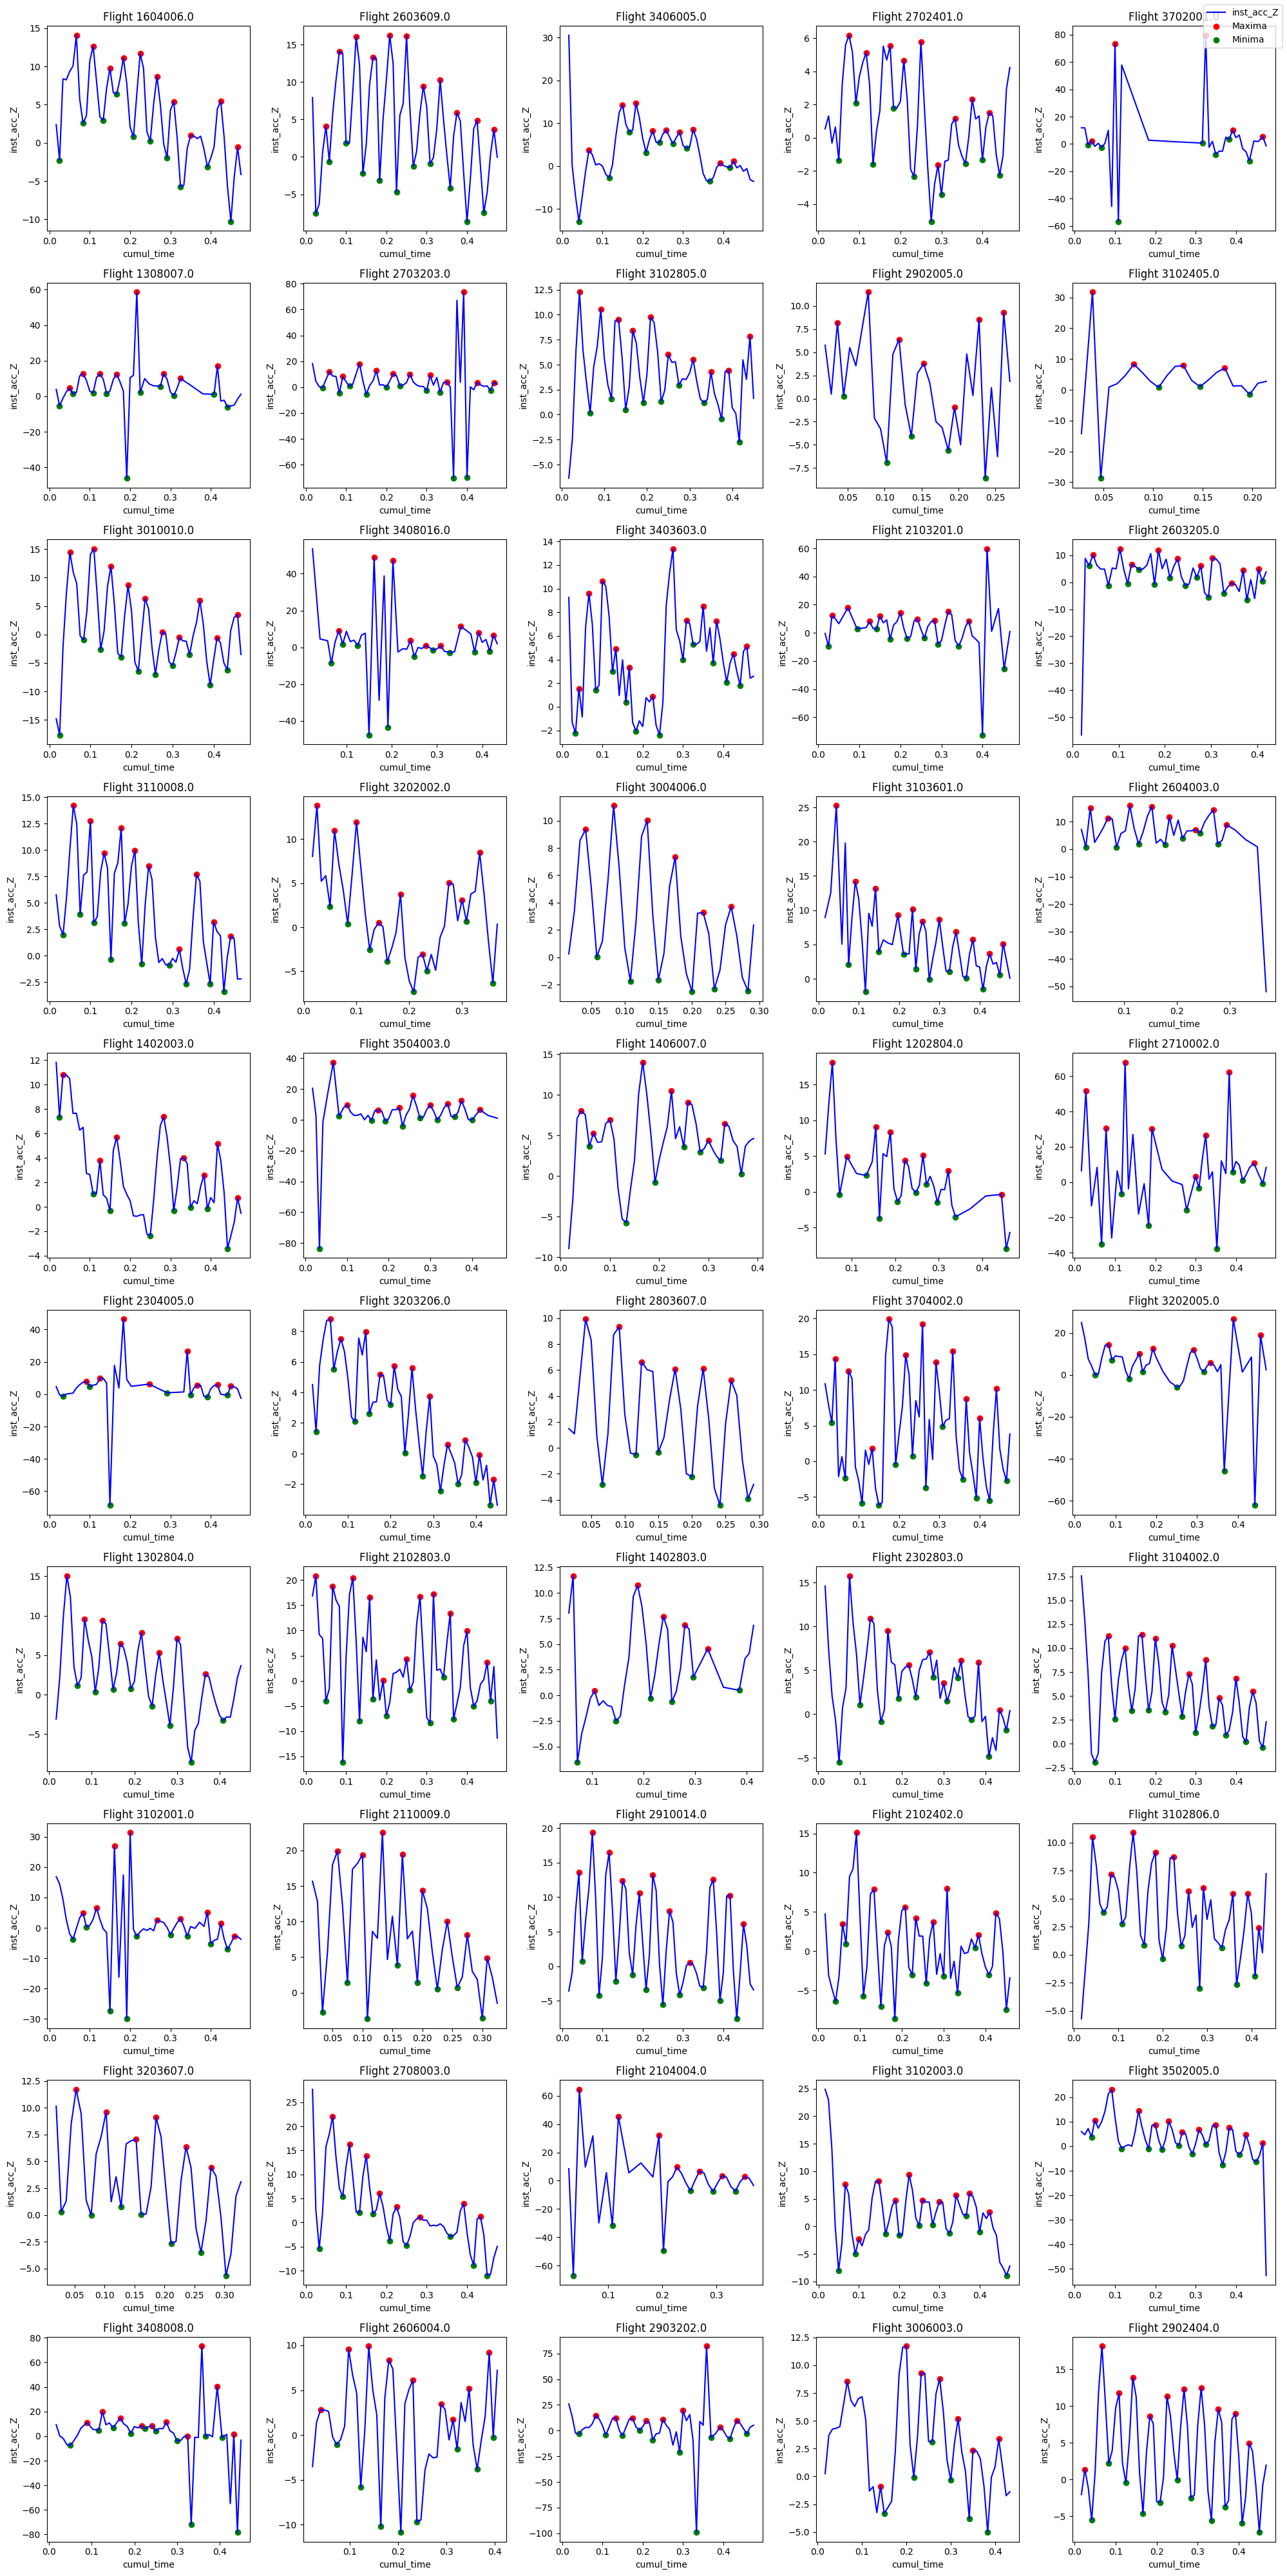

In [20]:

import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import pandas as pd

# Assuming you already have your flights DataFrame and sample_ids
sample_ids = flights['FlightID'].drop_duplicates().sample(n=50, random_state=72)

# Create a figure with 4x4 subplots
fig, axes = plt.subplots(10, 5, figsize=(20, 40))
axes = axes.flatten()

for i, flight_id in enumerate(sample_ids):
    # Filter data for this flight
    flight_data = flights[flights['FlightID'] == flight_id]
    x = flight_data['cumul_time'].values
    y = flight_data['inst_acc_Z'].values

    # Find maxima (peaks)
    peaks, _ = find_peaks(y, prominence=1, distance = 3)  # adjust parameters as needed

    # Find minima by inverting the signal
    minima, _ = find_peaks(-y, prominence=1, distance = 3)

    # Plot
    ax = axes[i]
    ax.plot(x, y, color='blue', label='inst_acc_Z')
    ax.scatter(x[peaks], y[peaks], color='red', label='Maxima')
    ax.scatter(x[minima], y[minima], color='green', label='Minima')
    ax.set_title(f'Flight {flight_id}')
    ax.set_xlabel('cumul_time')
    ax.set_ylabel('inst_acc_Z')

# Add a single legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')
plt.tight_layout()
plt.show()


## 11.2 compute wingbeats and upstroke / downstroke amplitudes

In [27]:
flight_outcome_updated = Tracking.compute_wingbeat_metrics(flights, flight_outcome)

c:\Users\jesu4036\Documents\flight-ontogeny\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\jesu4036\Documents\flight-ontogeny\.venv\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [28]:
print(flight_outcome.shape)
print(flight_outcome_updated.shape)

(937, 24)
(937, 28)


In [ ]:
flight_outcome_updated

## SAVE

In [29]:
flight_outcome_updated.to_csv('../data/takeoff/flight_outcome_full.csv')

Draw a histogram of peaks and try to put a filtering boundary. 

In [ ]:
flights

In [ ]:
flights.columns

something's wrong with this: from 0.0 to about 0.18 it is a bit of jump to say it is a wingbeat. 
Why? because it is not a triangle peak. 

### butterworth filter

In [ ]:
from scipy.signal import butter, filtfilt
import numpy as np
import matplotlib.pyplot as plt

# Sample rate and desired cutoff frequency (in Hz).
fs = 40
cutoff = 10 #when the most signals above are a noise

# Butterworth filter design
order = 4
nyquist = 0.5 * fs #Nyquist is 60 so cannot filter the 
normal_cutoff = cutoff / nyquist

# Get the filter coefficients
b, a = butter(order, normal_cutoff, btype='low', analog=False)

# Sample data: a noisy signal with a significant low-frequency component
data = valid_trials2[(valid_trials2.Bird == 'greenR-greenL') & (valid_trials2.Age == "80") & (valid_trials2.Takeoff == "10")]

# Select only the relevant columns
data_subset = data[['cumul_time', 'inst_acc_res']]

# Remove rows with NA in the inst_acc_Y column
data_subset = data_subset.dropna(subset=['inst_acc_res'])

t = data_subset['cumul_time']
data = data_subset['inst_acc_res']

# Apply the filter to the data
filtered_data = filtfilt(b, a, data)

# Plot the original and filtered signals
plt.figure()
plt.plot(t, data, label='Noisy signal')
plt.plot(t, filtered_data, label='Filtered signal', linewidth=2)
plt.xlabel('Time [seconds]')
plt.ylabel('Amplitude')
plt.legend()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# Load your data: replace this with your actual data loading
# Sample data: a noisy signal with a significant low-frequency component
data_subset = valid_trials2[(valid_trials2['Bird'] == 'redR-yellowL') & 
                            (valid_trials2['Age'] == "80") & 
                            (valid_trials2['Takeoff'] == "4")]

# Ensure the subset is not empty
if data_subset.empty:
    raise ValueError("No data found for the specified Bird, Age, and Takeoff.")

# Select only the relevant columns
data_subset = data_subset[['cumul_time', 'inst_acc_Y']]

# Remove rows with NA in the inst_acc_Y column
data_subset = data_subset.dropna(subset=['inst_acc_Y'])

# Extract time and data for analysis
t = data_subset['cumul_time'].values
data = data_subset['inst_acc_Y'].values

# Ensure the data is numeric and not empty
if not np.isfinite(data).all():
    raise ValueError("Data contains non-numeric or infinite values.")

# Plot the time-domain signal
plt.figure(figsize=(10, 6))
plt.plot(t, data, label='Time-Domain Signal')
plt.xlabel('Time [seconds]')
plt.ylabel('Amplitude')
plt.title('Time-Domain Signal')
plt.legend()
plt.grid(True)
plt.show()

# Compute the FFT
N = len(data)
T = t[1] - t[0]  # Sample spacing (time between samples)
yf = fft(data)
xf = fftfreq(N, T)[:N//2]

# Plot the frequency spectrum
plt.figure(figsize=(10, 6))
plt.plot(xf, 2.0/N * np.abs(yf[:N//2]), label='Frequency Spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.title('Frequency Spectrum of the Signal')
plt.grid(True)
plt.legend()
plt.show()


## append!

In [ ]:
import os
import pandas as pd
import glob

# Step 1: Check the current directory
current_directory = os.getcwd()
print(f"Current Directory: {current_directory}")

# Step 2: Check if "wingbeat" folder exists in the current directory
wingbeat_folder = os.path.join(current_directory, "wingbeats")

if not os.path.exists(wingbeat_folder):
    print(f"Directory 'wingbeats' not found in {current_directory}. Please check the path.")
else:
    print(f"'wingbeats' folder found at {wingbeat_folder}")

    # Step 3: List CSV files in the "wingbeat" folder
    csv_files = glob.glob(os.path.join(wingbeat_folder, "*_age_*_trial_*_wingbeat.csv"))
    
    if not csv_files:
        print("No matching CSV files found in the 'wingbeat' folder.")
    else:
        print(f"Found {len(csv_files)} CSV files in the 'wingbeats' folder.")
        print("Listing files:")
        for file in csv_files:
            print(file)
        
        # Step 4: Initialize an empty DataFrame to store the appended data
        combined_df = pd.DataFrame(columns=['Bird', 'Age', 'Takeoff', 'Time', 'Z_acc', 'Peak_type'])
        
        # Step 5: Process each CSV file
        for file_path in csv_files:
            file_name = os.path.basename(file_path)
            
            # Parse the file name to extract bird name, age, and trial number
            parts = file_name.split('_')
            bird_name = parts[0]
            age = parts[2]
            trial_number = parts[4]
            
            # Read the CSV file
            df = pd.read_csv(file_path)
            
            # Rename columns as per the requirement
            df.rename(columns={'x': 'Time', 'y': 'Z_acc', 'peaks': 'peak_type'}, inplace=True)
            
            # Add new columns for Bird, age, and Takeoff
            df['Bird'] = bird_name
            df['Age'] = age
            df['Takeoff'] = trial_number
            
            # Append the data to the combined DataFrame
            combined_df = pd.concat([combined_df, df], ignore_index=True)
        
        # Reorder columns to match the desired output
        combined_df = combined_df[['Bird', 'Age', 'Takeoff', 'Time', 'Z_acc', 'Peak_type']]
        
        # Save the combined DataFrame to a new CSV file
        output_file_path = os.path.join(wingbeat_folder, "combined_wingbeat_data.csv")
        combined_df.to_csv(output_file_path, index=False)
        
        print(f"Combined CSV file saved to {output_file_path}")


## read wingbeats 

In [ ]:
wingbeats = pd.read_csv('c:\\Users\\kmh\\Documents\\mocap\\TrackingMoCap\\notebooks\\wingbeats\\combined_wingbeat_data.csv', index_col = 0, 
                dtype =  {'Bird': str,'Age': int,'Takeoff':str, 
                          'Time':float, 'Z_acc': float, 
                          'peak_type': str} )

#rolling means applied

In [ ]:
wingbeats
#sort by time 
# wingbeat frequency 1/Time for minima - Time for previous minima 
# wingbeat amplitude maxima - minima in Z-acceleration, then integrated by maxima - minima time. 

# 12. filtering by Z-acceleration

## big peaks (bird, age, trial)
-yellowR-greyL, 60, 2
-yellowR-greyL, 80, 7
-yellowR-greyL, 100, 4
-yellowR-purpleL, 32, 1
-yellowR-purpleL, 32, 4
-greenR-greenL, 28, 4 
-greenR-greenL, 32, 3 
-greenR-greenL, 80, 13
-greenR-greenL, 80, 8 
-greenR-whiteL, 24, 4
-redR-purpleL, 24, 3
-greenR-whilteL, 40, 2, 3
-redR-purpleL, 100, 12
-redR-purpleL, 100, 18


## short wingbeats, low amplitude (noise or not? need re-editing)
-greenR, 28, 3
-greenR, 32, 10 (delete)
-greenR, 32, 4 
-greenR, 32, 8 
-greenR-greenL, 40, 2 
-greenR-greenL, 60, 1
-greenR-greenL, 60, 10 (weird)
-greenR-greenL, 60, 2 (delete)
-greenR-greenL, 60, 7 (weird)
-greenR-greenL, 80, 1 (delete)
-greenR-greenL, 80, 6 (delete)
-greenR-greenL, 80, 7 (delete)

## many similar peaks
-greenR-orangeL, 32, 1
-greenR-orangeL, 32, 5

## good model graphs
-greenR-purpleL, 36, 7
-greenR-purpleL, 80, 5
-greenR-whiteL, 20, all trials 

## to delete due to no peaks or very irregular 
-greyR-blackL, 80, 4 d
-greenR, 32, 10 d
-greenR, 60, 10 d
-greenR, 60, 2 d
-greenR, 80, 1 d
-greenR, 80, 6 d
-greenR, 80, 7 d
-pinkR-blackL, 24, 5 d
-pinkR-blueL, 28, 5 d
-pinkR-blueL, 32, 8 d
-pinkR-blueL, 36, 1 d
-pinkR-blueL, 60, 1 d
-pinkR-blueL, 100, 3 d
-redR-yellowL, 80, 3 (very irregular) d





### big peaks

In [ ]:
#first of all, filter big peaks and display at the range of +50, -50. 
import numpy as np
import pandas as pd
import pygame
import os

valid_trials2 = pd.read_csv('valid_trials2.csv', index_col = 0, 
                dtype =  {'index': str, 'Bird': str,'Age': int,'Takeoff':str, 'Note':str, 'Marker': int, 
                          'Time':float, 'Frame': float, 'X': float,'Y': float,'Z': float, 
                          'StationaryLabels': int, 'diff_X': float, 'diff_Y': float, 'diff_Z': float, 
                          'diff_Time': float, 'moving_distance': float, 'inst_V_res':float, 
                          'inst_V_X': float, 'inst_V_Y': float, 'inst_V_Z': float, 
                          'inst_acc_res': float, 'inst_acc_X': float, 'inst_acc_Y': float, 'inst_acc_Z':float, 'cumul_moving_distance': float, 'cumul_time': float} )

#rolling means applied
## big peaks (bird, age, trial)
yellowRgreyL_60_2 = valid_trials2[(valid_trials2.Bird == 'yellowR-greyL') & (valid_trials2.Age == 60) & (valid_trials2.Takeoff == "2")]
yellowRgreyL_80_7 = valid_trials2[(valid_trials2.Bird == 'yellowR-greyL') & (valid_trials2.Age == 80) & (valid_trials2.Takeoff == "7")]
yellowRgreyL_100_4 = valid_trials2[(valid_trials2.Bird == 'yellowR-greyL') & (valid_trials2.Age == 100) & (valid_trials2.Takeoff == "4")]

yellowRpurpleL_32_1 = valid_trials2[(valid_trials2.Bird == 'yellowR-purpleL') & (valid_trials2.Age == 32) & (valid_trials2.Takeoff == "1")]
yellowRpurpleL_32_4 = valid_trials2[(valid_trials2.Bird == 'yellowR-purpleL') & (valid_trials2.Age == 32) & (valid_trials2.Takeoff == "4")]

greenRgreenL_28_4 = valid_trials2[(valid_trials2.Bird == 'greenR-greenL') & (valid_trials2.Age == 28) & (valid_trials2.Takeoff == "4")]
greenRgreenL_32_3 = valid_trials2[(valid_trials2.Bird == 'greenR-greenL') & (valid_trials2.Age == 32) & (valid_trials2.Takeoff == "3")]
greenRgreenL_80_13  = valid_trials2[(valid_trials2.Bird == 'greenR-greenL') & (valid_trials2.Age == 80) & (valid_trials2.Takeoff == "13")]
greenRgreenL_80_8 = valid_trials2[(valid_trials2.Bird == 'greenR-greenL') & (valid_trials2.Age == 80) & (valid_trials2.Takeoff == "8")]

greenRwhiteL_24_4 = valid_trials2[(valid_trials2.Bird == 'greenR-greenL') & (valid_trials2.Age == 80) & (valid_trials2.Takeoff == "8")]
greenRwhilteL_40_2 = valid_trials2[(valid_trials2.Bird == 'greenR-whiteL') & (valid_trials2.Age == 40) & (valid_trials2.Takeoff == "2")]
greenRwhilteL_40_3 = valid_trials2[(valid_trials2.Bird == 'greenR-whiteL') & (valid_trials2.Age == 40) & (valid_trials2.Takeoff == "3")]

redRpurpleL_24_3 = valid_trials2[(valid_trials2.Bird == 'redR-purpleL') & (valid_trials2.Age == 24) & (valid_trials2.Takeoff == "3")]
redRpurpleL_100_12 = valid_trials2[(valid_trials2.Bird == 'redR-purpleL') & (valid_trials2.Age == 100) & (valid_trials2.Takeoff == "12")]
redRpurpleL_100_18 = valid_trials2[(valid_trials2.Bird == 'redR-purpleL') & (valid_trials2.Age == 100) & (valid_trials2.Takeoff == "18")]


bigpeaks = [yellowRgreyL_60_2, yellowRgreyL_80_7, yellowRgreyL_100_4, yellowRpurpleL_32_1, yellowRpurpleL_32_4, greenRgreenL_28_4, greenRgreenL_32_3, 
            greenRgreenL_80_13, greenRgreenL_80_8, greenRwhiteL_24_4, greenRwhilteL_40_2, greenRwhilteL_40_3, redRpurpleL_24_3, redRpurpleL_100_12, redRpurpleL_100_18]

bigpeaks_df = pd.concat(bigpeaks, ignore_index = True)

# Function to map data points to screen coordinates
def map_to_screen(x_val, y_val, screen_size):
    x_min, x_max = 0, 0.7
    y_min, y_max = -100, 100
    x_screen = int((x_val - x_min) / (x_max - x_min) * screen_size[0])
    y_screen = int((1 - (y_val - y_min) / (y_max - y_min)) * screen_size[1])
    return x_screen, y_screen

# Function to draw axes with tick marks
def draw_axes(screen, screen_size, x_ticks, y_ticks):
    font = pygame.font.SysFont(None, 36)
    black = (0, 0, 0)
    
    # Draw x-axis
    pygame.draw.line(screen, black, (50, screen_size[1] - 50), (screen_size[0] - 50, screen_size[1] - 50), 2)
    x_label = font.render('cumul_time', True, black)
    screen.blit(x_label, (screen_size[0] - 200, screen_size[1] - 40))
    
    # Draw y-axis
    pygame.draw.line(screen, black, (50, 50), (50, screen_size[1] - 50), 2)
    y_label = font.render('inst_acc_Z', True, black)
    screen.blit(y_label, (10, 10))
    
    # Draw tick marks on x-axis
    for x_tick in x_ticks:
        tick_pos = map_to_screen(x_tick, -30, screen_size)[0]
        pygame.draw.line(screen, black, (tick_pos, screen_size[1] - 55), (tick_pos, screen_size[1] - 45), 2)
        tick_label = font.render(f"{x_tick:.2f}", True, black)
        screen.blit(tick_label, (tick_pos - 15, screen_size[1] - 40))
    
    # Draw tick marks on y-axis
    for y_tick in y_ticks:
        tick_pos = map_to_screen(0, y_tick, screen_size)[1]
        pygame.draw.line(screen, black, (45, tick_pos), (55, tick_pos), 2)
        tick_label = font.render(f"{y_tick:.1f}", True, black)
        screen.blit(tick_label, (10, tick_pos - 10))

# Function to handle pygame events and display the graph
def handle_pygame_events(x, y, screen_size, bird, age, trial):
    pygame.init()
    screen = pygame.display.set_mode(screen_size)
    pygame.display.set_caption('Click to Record Data')

    white = (255, 255, 255)
    blue = (0, 0, 255)
    green = (0, 255, 0)
    red = (255, 0, 0)
    black = (0, 0, 0)

    clicked_points = []
    running = True
    
    while running:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False
            elif event.type == pygame.MOUSEBUTTONDOWN:
                mouse_pos = pygame.mouse.get_pos()
                x_val = (mouse_pos[0] / screen_size[0]) * 0.7
                y_val = (1 - (mouse_pos[1] / screen_size[1])) * 200 - 100
                closest_index = np.argmin(np.abs(x - x_val))
                x_val = x[closest_index]
                y_val = y[closest_index]

                if event.button == 1:  # Left click
                    peak_type = 'minima'
                    print(f"Clicked Point - X: {x_val}, Y: {y_val}, Peak Type: {peak_type}")
                    clicked_points.append({'x': x_val, 'y': y_val, 'peaks': peak_type})
                elif event.button == 3:  # Right click
                    peak_type = 'maxima'
                    print(f"Clicked Point - X: {x_val}, Y: {y_val}, Peak Type: {peak_type}")
                    clicked_points.append({'x': x_val, 'y': y_val, 'peaks': peak_type})
                elif event.button == 2:  # Middle click
                    clicked_points = [p for p in clicked_points if not (p['x'] == x_val and p['y'] == y_val)]
                    print(f"Removed Point - X: {x_val}, Y: {y_val}")

        screen.fill(white)
        
        # Draw line plot
        for i in range(len(x) - 1):
            x1, y1 = map_to_screen(x[i], y[i], screen_size)
            x2, y2 = map_to_screen(x[i + 1], y[i + 1], screen_size)
            pygame.draw.line(screen, blue, (x1, y1), (x2, y2), 2)
        
        # Draw clicked points
        for point in clicked_points:
            px, py = map_to_screen(point['x'], point['y'], screen_size)
            color = green if point['peaks'] == 'minima' else red
            pygame.draw.circle(screen, color, (px, py), 10, 1)
        
        # Draw axes with tick marks
        x_ticks = np.linspace(0, 0.7, 8)
        y_ticks = np.linspace(-100, 100, 6)
        draw_axes(screen, screen_size, x_ticks, y_ticks)
        
        # Display bird's name, age, and trial
        font = pygame.font.SysFont(None, 48)
        info_text = f"Bird: {bird}, Age: {age}, Trial: {trial}"
        info_surface = font.render(info_text, True, black)
        screen.blit(info_surface, (screen_size[0] // 2 - info_surface.get_width() // 2, 10))
        
        pygame.display.flip()

    pygame.quit()
    return clicked_points

# Main loop to display each graph sequentially
unique_birds = bigpeaks_df['Bird'].unique()

# Create the 'wingbeats' directory if it doesn't exist
output_dir = 'wingbeats'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for bird in unique_birds:
    bird_data = bigpeaks_df[bigpeaks_df['Bird'] == bird]
    unique_ages = bird_data['Age'].unique()
    
    for age in unique_ages:
        age_data = bird_data[bird_data['Age'] == age]
        unique_trials = age_data['Takeoff'].unique()
        
        for trial in unique_trials:
            current_sequence = age_data[age_data['Takeoff'] == trial]

            # Filter out rows with NaN values in 'cumul_time' or 'inst_acc_Z'
            filtered_sequence = current_sequence.dropna(subset=['cumul_time', 'inst_acc_Z'])
            
            # Extract the filtered data
            x = filtered_sequence['cumul_time'].values
            y = filtered_sequence['inst_acc_Z'].values

            # Define fixed screen size
            screen_size = (800, 600)

            # Display the graph and handle events
            clicked_points = handle_pygame_events(x, y, screen_size, bird, age, trial)

            # Save the clicked points after the graph is closed
            if clicked_points:
                df = pd.DataFrame(clicked_points)
                file_name = os.path.join(output_dir, f'{bird}_age_{age}_trial_{trial}_wingbeat.csv')
                df.to_csv(file_name, index=False)
                print(f"Data saved to '{file_name}'")


### low amplitude

In [ ]:
import numpy as np
import pandas as pd
import pygame
import os

valid_trials2 = pd.read_csv('valid_trials2.csv', index_col = 0, 
                dtype =  {'index': str, 'Bird': str,'Age': int,'Takeoff':str, 'Note':str, 'Marker': int, 
                          'Time':float, 'Frame': float, 'X': float,'Y': float,'Z': float, 
                          'StationaryLabels': int, 'diff_X': float, 'diff_Y': float, 'diff_Z': float, 
                          'diff_Time': float, 'moving_distance': float, 'inst_V_res':float, 
                          'inst_V_X': float, 'inst_V_Y': float, 'inst_V_Z': float, 
                          'inst_acc_res': float, 'inst_acc_X': float, 'inst_acc_Y': float, 'inst_acc_Z':float, 'cumul_moving_distance': float, 'cumul_time': float} )

greenR_28_3 = valid_trials2[(valid_trials2.Bird == 'greenR') & (valid_trials2.Age == 28) & (valid_trials2.Takeoff == "3")]
greenR_32_10 = valid_trials2[(valid_trials2.Bird == 'greenR') & (valid_trials2.Age == 32) & (valid_trials2.Takeoff == "10")]
greenR_32_4 = valid_trials2[(valid_trials2.Bird == 'greenR') & (valid_trials2.Age == 32) & (valid_trials2.Takeoff == "4")]
greenR_32_8 = valid_trials2[(valid_trials2.Bird == 'greenR') & (valid_trials2.Age == 32) & (valid_trials2.Takeoff == "8")]
greenRgreenL_40_2 = valid_trials2[(valid_trials2.Bird == 'greenR-greenL') & (valid_trials2.Age == 40) & (valid_trials2.Takeoff == "2")]
greenRgreenL_60_1 = valid_trials2[(valid_trials2.Bird == 'greenR-greenL') & (valid_trials2.Age == 60) & (valid_trials2.Takeoff == "1")]
greenRgreenL_60_10 = valid_trials2[(valid_trials2.Bird == 'greenR-greenL') & (valid_trials2.Age == 60) & (valid_trials2.Takeoff == "10")]
greenRgreenL_60_2 = valid_trials2[(valid_trials2.Bird == 'greenR-greenL') & (valid_trials2.Age == 60) & (valid_trials2.Takeoff == "2")]
greenRgreenL_60_7 = valid_trials2[(valid_trials2.Bird == 'greenR-greenL') & (valid_trials2.Age == 60) & (valid_trials2.Takeoff == "7")]
greenRgreenL_80_1 = valid_trials2[(valid_trials2.Bird == 'greenR-greenL') & (valid_trials2.Age == 80) & (valid_trials2.Takeoff == "1")]
greenRgreenL_80_6 = valid_trials2[(valid_trials2.Bird == 'greenR-greenL') & (valid_trials2.Age == 80) & (valid_trials2.Takeoff == "6")]
greenRgreenL_80_7 = valid_trials2[(valid_trials2.Bird == 'greenR-greenL') & (valid_trials2.Age == 80) & (valid_trials2.Takeoff == "7")]

## many similar peaks
greenRorangeL_32_1 = valid_trials2[(valid_trials2.Bird == 'greenR-orangeL') & (valid_trials2.Age == 32) & (valid_trials2.Takeoff == "1")]
greenRorangeL_32_5 = valid_trials2[(valid_trials2.Bird == 'greenR-orangeL') & (valid_trials2.Age == 32) & (valid_trials2.Takeoff == "5")]

lowamp = [greenR_28_3, greenR_32_10, greenR_32_4, greenR_32_8, greenRgreenL_40_2, greenRgreenL_60_1, greenRgreenL_60_10, greenRgreenL_60_2, greenRgreenL_60_7, greenRgreenL_80_1, greenRgreenL_80_6, greenRgreenL_80_7]

lowamp_df = pd.concat(lowamp, ignore_index = True)

# Function to map data points to screen coordinates
def map_to_screen(x_val, y_val, screen_size):
    x_min, x_max = 0, 0.5
    y_min, y_max = -30, 30
    x_screen = int((x_val - x_min) / (x_max - x_min) * (screen_size[0] - 1))
    y_screen = int((1 - (y_val - y_min) / (y_max - y_min)) * (screen_size[1] - 1))
    return x_screen, y_screen

# Function to draw axes with tick marks
def draw_axes(screen, screen_size, x_ticks, y_ticks):
    font = pygame.font.SysFont(None, 36)
    black = (0, 0, 0)
    
    # Draw x-axis
    pygame.draw.line(screen, black, (50, screen_size[1] - 50), (screen_size[0] - 50, screen_size[1] - 50), 2)
    x_label = font.render('cumul_time', True, black)
    screen.blit(x_label, (screen_size[0] - 200, screen_size[1] - 40))
    
    # Draw y-axis
    pygame.draw.line(screen, black, (50, 50), (50, screen_size[1] - 50), 2)
    y_label = font.render('inst_acc_Z', True, black)
    screen.blit(y_label, (10, 10))
    
    # Draw tick marks on x-axis
    for x_tick in x_ticks:
        tick_pos = map_to_screen(x_tick, -30, screen_size)[0]
        pygame.draw.line(screen, black, (tick_pos, screen_size[1] - 55), (tick_pos, screen_size[1] - 45), 2)
        tick_label = font.render(f"{x_tick:.2f}", True, black)
        screen.blit(tick_label, (tick_pos - 15, screen_size[1] - 40))
    
    # Draw tick marks on y-axis
    for y_tick in y_ticks:
        tick_pos = map_to_screen(0, y_tick, screen_size)[1]
        pygame.draw.line(screen, black, (45, tick_pos), (55, tick_pos), 2)
        tick_label = font.render(f"{y_tick:.1f}", True, black)
        screen.blit(tick_label, (10, tick_pos - 10))

# Function to handle pygame events and display the graph
def handle_pygame_events(x, y, screen_size, bird, age, trial):
    pygame.init()
    screen = pygame.display.set_mode(screen_size)
    pygame.display.set_caption('Click to Record Data')

    white = (255, 255, 255)
    blue = (0, 0, 255)
    green = (0, 255, 0)
    red = (255, 0, 0)
    black = (0, 0, 0)

    clicked_points = []
    running = True
    
    while running:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False
            elif event.type == pygame.MOUSEBUTTONDOWN:
                mouse_pos = pygame.mouse.get_pos()
                x_val = (mouse_pos[0] / screen_size[0]) * 0.5
                y_val = (1 - (mouse_pos[1] / screen_size[1])) * 60 - 30
                closest_index = np.argmin(np.abs(x - x_val))
                x_val = x[closest_index]
                y_val = y[closest_index]

                if event.button == 1:  # Left click
                    peak_type = 'minima'
                    print(f"Clicked Point - X: {x_val}, Y: {y_val}, Peak Type: {peak_type}")
                    clicked_points.append({'x': x_val, 'y': y_val, 'peaks': peak_type})
                elif event.button == 3:  # Right click
                    peak_type = 'maxima'
                    print(f"Clicked Point - X: {x_val}, Y: {y_val}, Peak Type: {peak_type}")
                    clicked_points.append({'x': x_val, 'y': y_val, 'peaks': peak_type})
                elif event.button == 2:  # Middle click
                    clicked_points = [p for p in clicked_points if not (p['x'] == x_val and p['y'] == y_val)]
                    print(f"Removed Point - X: {x_val}, Y: {y_val}")

        screen.fill(white)
        
        # Draw line plot
        for i in range(len(x) - 1):
            x1, y1 = map_to_screen(x[i], y[i], screen_size)
            x2, y2 = map_to_screen(x[i + 1], y[i + 1], screen_size)
            pygame.draw.line(screen, blue, (x1, y1), (x2, y2), 2)
        
        # Draw clicked points
        for point in clicked_points:
            px, py = map_to_screen(point['x'], point['y'], screen_size)
            color = green if point['peaks'] == 'minima' else red
            pygame.draw.circle(screen, color, (px, py), 10, 1)
        
        # Draw axes with tick marks
        x_ticks = np.linspace(0, 0.5, 5)
        y_ticks = np.linspace(-30, 30, 5)
        draw_axes(screen, screen_size, x_ticks, y_ticks)
        
        # Display bird's name, age, and trial
        font = pygame.font.SysFont(None, 48)
        info_text = f"Bird: {bird}, Age: {age}, Trial: {trial}"
        info_surface = font.render(info_text, True, black)
        screen.blit(info_surface, (screen_size[0] // 2 - info_surface.get_width() // 2, 10))
        
        pygame.display.flip()

    pygame.quit()
    return clicked_points

# Main loop to display each graph sequentially
unique_birds = lowamp_df['Bird'].unique()

# Create the 'wingbeats' directory if it doesn't exist
output_dir = 'wingbeats'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for bird in unique_birds:
    bird_data = lowamp_df[lowamp_df['Bird'] == bird]
    unique_ages = bird_data['Age'].unique()
    
    for age in unique_ages:
        age_data = bird_data[bird_data['Age'] == age]
        unique_trials = age_data['Takeoff'].unique()
        
        for trial in unique_trials:
            current_sequence = age_data[age_data['Takeoff'] == trial]

            # Filter out rows with NaN values in 'cumul_time' or 'inst_acc_Z'
            filtered_sequence = current_sequence.dropna(subset=['cumul_time', 'inst_acc_Z'])
            
            # Extract the filtered data
            x = filtered_sequence['cumul_time'].values
            y = filtered_sequence['inst_acc_Z'].values

            # Define fixed screen size
            screen_size = (800, 600)

            # Display the graph and handle events
            clicked_points = handle_pygame_events(x, y, screen_size, bird, age, trial)

            # Save the clicked points after the graph is closed
            if clicked_points:
                df = pd.DataFrame(clicked_points)
                file_name = os.path.join(output_dir, f'{bird}_age_{age}_trial_{trial}_wingbeat.csv')
                df.to_csv(file_name, index=False)
                print(f"Data saved to '{file_name}'")


## append one again!

In [ ]:
import os
import pandas as pd
import glob

# Step 1: Check the current directory
current_directory = os.getcwd()
print(f"Current Directory: {current_directory}")

# Step 2: Check if "wingbeat" folder exists in the current directory
wingbeat_folder = os.path.join(current_directory, "wingbeats")

if not os.path.exists(wingbeat_folder):
    print(f"Directory 'wingbeats' not found in {current_directory}. Please check the path.")
else:
    print(f"'wingbeats' folder found at {wingbeat_folder}")

    # Step 3: List CSV files in the "wingbeat" folder
    csv_files = glob.glob(os.path.join(wingbeat_folder, "*_age_*_trial_*_wingbeat.csv"))
    
    if not csv_files:
        print("No matching CSV files found in the 'wingbeat' folder.")
    else:
        print(f"Found {len(csv_files)} CSV files in the 'wingbeats' folder.")
        print("Listing files:")
        for file in csv_files:
            print(file)
        
        # Step 4: Initialize an empty DataFrame to store the appended data
        combined_df = pd.DataFrame(columns=['Bird', 'Age', 'Takeoff', 'Time', 'Z_acc', 'peaks'])
        
        # Step 5: Process each CSV file
        for file_path in csv_files:
            file_name = os.path.basename(file_path)
            
            # Parse the file name to extract bird name, age, and trial number
            parts = file_name.split('_')
            bird_name = parts[0]
            age = parts[2]
            trial_number = parts[4]
            
            # Read the CSV file
            df = pd.read_csv(file_path)
            
            # Rename columns as per the requirement
            df.rename(columns={'x': 'Time', 'y': 'Z_acc', 'peaks': 'Peak_type'}, inplace=True)
            
            # Add new columns for Bird, age, and Takeoff
            df['Bird'] = bird_name
            df['Age'] = age
            df['Takeoff'] = trial_number
            
            # Append the data to the combined DataFrame
            combined_df = pd.concat([combined_df, df], ignore_index=True)
        
        # Reorder columns to match the desired output
        combined_df = combined_df[['Bird', 'Age', 'Takeoff', 'Time', 'Z_acc', 'Peak_type']]
        
        # Save the combined DataFrame to a new CSV file
        output_file_path = os.path.join(wingbeat_folder, "combined_wingbeat_data.csv")
        combined_df.to_csv(output_file_path, index=False)
        
        print(f"Combined CSV file saved to {output_file_path}")


## WINGBEATS - data

In [ ]:
valid_trials2.head(5)

In [ ]:
wingbeats = pd.read_csv('c:\\Users\\kmh\\Documents\\mocap\\TrackingMoCap\\notebooks\\wingbeats\\combined_wingbeat_data.csv', 
                dtype =  {'Bird': str,'Age': int,'Takeoff':str, 
                          'Time':float, 'Z_acc': float, 
                          'Peak_type': str} )


In [ ]:
#joing winbgeats to valid_trails2 merging by Bird, Age, Takeoff, Time, and 

In [ ]:
print(wingbeats.head(5))
print(wingbeats.shape)

In [ ]:
wingbeats.columns

In [ ]:
#for each bird, age, and takeoff, sort by time, then calculate wingbeat frequency by
#1/ Time maxima - lag(maxima)

In [ ]:
import pandas as pd
import numpy as np

# Sample data (replace with actual dataset loading)

# Load your dataset
df = pd.DataFrame(wingbeats)

# Rename column 'Z_acc' to 'inst_acc_Z'
df.rename(columns={'Z_acc': 'inst_acc_Z'}, inplace=True)

# Sort the dataframe by 'Time'
df = df.sort_values('Time').reset_index(drop=True)

# Initialize lists to hold results
results_maxima = []
results_combined = []

# Group by 'Bird', 'Age', and 'Takeoff'
groups = df.groupby(['Bird', 'Age', 'Takeoff'])

for (bird, age, takeoff), group_df in groups:
    print(f"\nProcessing Bird: {bird}, Age: {age}, Takeoff: {takeoff}")

    # Separate maxima and minima
    maxima_df = group_df[group_df['Peak_type'] == 'maxima'].reset_index(drop=True)
    minima_df = group_df[group_df['Peak_type'] == 'minima'].reset_index(drop=True)

    # Calculate wingbeat frequency for maxima
    maxima_df['time_diff'] = maxima_df['Time'].diff()  # Time difference between subsequent maxima
    maxima_df['wingbeat_frequency'] = 1 / maxima_df['time_diff']  # Frequency is 1 over time difference
    maxima_df['wingbeat_frequency'] = maxima_df['wingbeat_frequency'].fillna(0)  # Fill missing values

    # Combine maxima_df and minima_df into one DataFrame
    combined_df = pd.concat([maxima_df, minima_df], ignore_index=True).sort_values('Time').reset_index(drop=True)
    combined_df['inst_acc_Z'] = combined_df['inst_acc_Z'].fillna(0)  # Fill missing values in 'inst_acc_Z'

    # Store results
    results_maxima.append(maxima_df[['Time', 'inst_acc_Z', 'wingbeat_frequency']])
    results_combined.append(combined_df)

# Concatenate all results into single DataFrames
all_maxima = pd.concat(results_maxima, ignore_index=True)
all_combined = pd.concat(results_combined, ignore_index=True)

# Print results
print("\nMaxima DataFrame with Wingbeat Frequency:")
print(all_maxima)

print("\nCombined DataFrame with Maxima and Minima:")
print(all_combined)

# Save results to CSV files
all_maxima.to_csv('wingbeat_frequencies.csv', index=False)
all_combined.to_csv('combined_data.csv', index=False)

print("Results have been saved to CSV files.")


In [ ]:
print(all_combined.head(10))
print(all_combined.shape)


In [ ]:
# make a graph per bird, x-axis age, and y-axis median wingbeat frequency

In [ ]:
valid_trials2.head(5)

In [ ]:
valid_trials2.columns
#maybe just filter 'Bird', 'Age', 'Takeoff', 'Time', 'inst_V_Z', and inst_acc_Z' from valid_trials. 
wing_kinematics = valid_trials2[['Bird', 'Age', 'Takeoff', 'cumul_time', 'inst_V_Z', 'inst_acc_Z']]

In [ ]:
#rename cumul_Time to Time for wing_kinematics
#it will be confusing because in valid_trials2, 'Time' is absolute time when 'cumul_time' is time since the maximum leg force. 
df.rename(columns={'cumul_time': 'Time'}, inplace=True)


# Drop rows with NaN in 'Time' or 'inst_acc_Z'
wing_kinematics = wing_kinematics.dropna(subset=['Time', 'inst_acc_Z'])
all_combined = all_combined.dropna(subset=['Time', 'inst_acc_Z'])

wing_kinematics['Time'] = pd.to_numeric(wing_kinematics['Time'], errors = 'coerce')
wing_kinematics['inst_acc_Z'] = pd.to_numeric(wing_kinematics['inst_acc_Z'], errors = 'coerce')

all_combined['Time'] = pd.to_numeric(all_combined['Time'])
all_combined['inst_acc_Z'] = pd.to_numeric(all_combined['inst_acc_Z'])

# Ensure sorting for pd.merge_asof (required for asof)
wing_kinematics = wing_kinematics.sort_values(by=['Bird', 'Age', 'Takeoff', 'Time'])
all_combined = all_combined.sort_values(by=['Bird', 'Age', 'Takeoff', 'Time'])

# Double-check if sorting was successful (optional debug step)
print(wing_kinematics[['Bird', 'Age', 'Takeoff', 'Time']].head(10))
print(all_combined[['Bird', 'Age', 'Takeoff', 'Time']].head(10))



In [ ]:
# Perform approximate merge on 'Time' using pd.merge_asof
merged_df = pd.merge(
    wing_kinematics, 
    all_combined, 
    on = ['Bird', 'Age', 'Takeoff', 'Time'], 
    how = 'inner'
)

# Calculate the difference in 'inst_acc_Z'
merged_df['inst_acc_Z_diff'] = np.abs(merged_df['inst_acc_Z_x'] - merged_df['inst_acc_Z_y'])


In [ ]:
sns.histplot(data = merged_df, x= "inst_acc_Z_diff")

In [ ]:
merged_df.shape #7892

In [ ]:
7892*0.01 #78

In [ ]:
largediff = merged_df[merged_df['inst_acc_Z_diff'] != 0]
sns.histplot(data = largediff, x= "inst_acc_Z_diff")
#the largest difference is 3.5 * 10^(-15) so it's fine! 

In [ ]:
largediff.to_csv('largediff.csv')

In [ ]:
threshold = 0.00000001
smalldiff = largediff[largediff['inst_acc_Z_diff'] > threshold]
sns.histplot(data = smalldiff, x= "inst_acc_Z_diff")
#none of the data more than such small threshold. 

In [ ]:
#filter the dataset where 'inst_acc_Z_diff' is not 0. 


In [ ]:
print(merged_df.head(5))
print(merged_df.shape) #7892

## duration & amplitude

In [ ]:
import pandas as pd
from scipy.integrate import cumulative_trapezoid as cumtrapz


# Assuming `df` is your DataFrame with the columns 'Bird', 'Age', 'Takeoff', 'cumul_time', 'inst_V_Z', 'inst_acc_Z', 'peak_type', 'wingbeat_frequency'

# Step 1: Sort the DataFrame by 'Bird', 'Age', 'Takeoff', and 'cumul_time' to ensure it’s in the correct order
merged_df = merged_df.sort_values(by=['Bird', 'Age', 'Takeoff', 'cumul_time'])

# Step 2: Initialize empty lists to store duration and stroke_type
durations = []
stroke_types = []

# Step 3: Iterate through the DataFrame to calculate 'duration' and 'stroke_type'
for i in range(1, len(df)):
    if merged_df.iloc[i]['Peak_type'] == 'minima' and merged_df.iloc[i-1]['Peak_type'] == 'maxima':
        # Downstroke: minima follows maxima
        duration = merged_df.iloc[i]['cumul_time'] - merged_df.iloc[i-1]['cumul_time']
        durations.append(duration)
        stroke_types.append('downstroke')
    elif merged_df.iloc[i]['Peak_type'] == 'maxima' and merged_df.iloc[i-1]['Peak_type'] == 'minima':
        # Upstroke: maxima follows minima
        duration = merged_df.iloc[i]['cumul_time'] - merged_df.iloc[i-1]['cumul_time']
        durations.append(duration)
        stroke_types.append('upstroke')
    else:
        durations.append(None)
        stroke_types.append(None)

# Add the calculated columns to the DataFrame
merged_df['duration'] = [None] + durations  # Padding with None at the start for alignment
merged_df['stroke_type'] = [None] + stroke_types

# Step 4: Calculate Wingbeat Amplitude (displacement)
# Assuming displacement is the integral of velocity (inst_V_Z) over time (cumul_time)
merged_df['amp1'] = merged_df['inst_V_Z'] * merged_df['duration']

# Integrate the acceleration if necessary or use inst_V_Z and cumul_time for displacement
# Here we keep it simple by just multiplying velocity by duration as an approximation

# You may want to use more advanced methods (e.g., trapezoidal rule) to integrate the velocity over the stroke
# amplitude = integral of inst_V_Z over the duration of a stroke.

# Example of a more sophisticated displacement calculation using trapezoidal integration

merged_df['amp2'] = cumtrapz(merged_df['inst_V_Z'], merged_df['cumul_time'], initial=0)

# Final result
print(merged_df)


In [ ]:
merged_df.columns

In [ ]:
sns.histplot(data = merged_df, x = 'amp1') #simple approach seems to work better

## graph 1: median wingbeat freqeuncy by age, colored by individual bird 

- wingbeat frequency becomes more variable by age. 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is your DataFrame with the relevant columns
# Calculating the median wingbeat frequency for each Bird and Age
median_wingbeat_freq = merged_df.groupby(['Bird', 'Age'])['wingbeat_frequency'].median().reset_index()

# Plotting using seaborn
plt.figure(figsize=(10, 6))
sns.lineplot(data=median_wingbeat_freq, x='Age', y='wingbeat_frequency', hue='Bird', marker='o')

# Adding labels and title
plt.xlabel('Age')
plt.ylabel('Median Wingbeat Frequency')
plt.title('Median Wingbeat Frequency by Age, Colored by Bird')
plt.legend(title='Bird', bbox_to_anchor=(1.25, 1), loc='upper right', borderaxespad=0.)
plt.grid(True)

# Show the plot
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is your DataFrame with the relevant columns
# Calculating the median wingbeat frequency for each Bird and Age
median_wingbeat_freq = merged_df.groupby(['Bird', 'Age'])['wingbeat_frequency'].median().reset_index()

# Plotting using seaborn
plt.figure(figsize=(10, 6))
sns.lineplot(data=median_wingbeat_freq, x='Age', y='wingbeat_frequency', marker='o') #95 confidence interval.

# Adding labels and title
plt.xlabel('Age')
plt.ylabel('Median Wingbeat Frequency')
plt.title('Median Wingbeat Frequency by Age')
plt.grid(True)

# Show the plot
plt.show()

In [ ]:
sns.boxplot(data=median_wingbeat_freq, x='Age', y='wingbeat_frequency')


## graph 2: median duration by age, colored by upstroke and downstroke 
- stroke duration decreases by age

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is your DataFrame with the relevant columns
# Calculating the median wingbeat frequency for each Bird and Age
median_duration = merged_df.groupby(['Bird', 'Age', 'stroke_type'])['duration'].median().reset_index()

# Plotting using seaborn
plt.figure(figsize=(10, 6))
sns.lineplot(data=median_duration, x='Age', y='duration', hue='stroke_type', marker='o')

# Adding labels and title
plt.xlabel('Age')
plt.ylabel('Median stroke duration')
plt.title('Median stroke duration by stroke type')
#plt.legend(title='Bird', bbox_to_anchor=(1.25, 1), loc='upper right', borderaxespad=0.)
plt.grid(True)

# Show the plot
plt.show()

In [ ]:
sns.boxplot(data=median_duration, x='Age', y='duration', hue='stroke_type')


## graph 3: wingbeat amplitude by age, colored by upstroke and downstroke
- Amplitude decreases by age

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is your DataFrame with the relevant columns
# Calculating the median wingbeat frequency for each Bird and Age
median_amplitude = merged_df.groupby(['Bird', 'Age', 'stroke_type'])['amp1'].median().reset_index()

# Plotting using seaborn
plt.figure(figsize=(10, 6))
sns.lineplot(data=median_amplitude, x='Age', y='amp1', hue='stroke_type', marker='o')

# Adding labels and title
plt.xlabel('Age')
plt.ylabel('Median stroke amplitude')
plt.title('Median amplitude by stroke type')
#plt.legend(title='Bird', bbox_to_anchor=(1.25, 1), loc='upper right', borderaxespad=0.)
plt.grid(True)

# Show the plot
plt.show()

In [ ]:
merged_df

In [ ]:
sns.boxplot(data = median_amplitude, x='Age', y='amp1', hue='stroke_type')
plt.xlabel('Age')
plt.ylabel('Median stroke amplitude')
plt.title('Median amplitude by stroke type')
#plt.legend(title='Bird', bbox_to_anchor=(1.25, 1), loc='upper right', borderaxespad=0.)
plt.grid(True)

# Show the plot
plt.show()

In conclusion, clear decrease in stroke amplitdue and duration but not a clear increase in wingbeat frequency although wingbeat frequency shows wider range as age increases. Flap and bounding may affect this and also the effect of the wings. 